# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as scp
from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm
import statsmodels.stats.multitest as multi

In [2]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

In [3]:
from matplotlib.pyplot import FormatStrFormatter

In [4]:
import matplotlib.patches as mpatches

In [5]:
# Toggle as needed
import warnings
warnings.filterwarnings("ignore")

# Functions

In [6]:
def response_rate_logit(x,y):
    log_reg = sm.Logit(y,sm.add_constant(x)).fit(method='lbfgs',maxiter=99999,disp=0)
    return log_reg.pvalues,log_reg.params

In [7]:
def survival_curve_pair(df,var_label,durations_label,event_observed_label):
    
    fig=plt.figure(figsize=(6,4))
    ax = fig.add_subplot(111)
    
    med_pfs = []
    df_trim = df.dropna(subset=[var_label,durations_label,event_observed_label])
    df_onehot = pd.get_dummies(df_trim[var_label])
    
    kmf_exp = KaplanMeierFitter()
    df_surv = df_trim[df_trim[var_label]==df_onehot.columns[0]][[durations_label,event_observed_label]]
    ax = kmf_exp.fit(df_surv[durations_label],df_surv[event_observed_label],label=df_onehot.columns[0]).\
            plot_survival_function(ax=ax,show_censors=False,ci_show=False)
    med_pfs.append([var_label,df_onehot.columns[0],kmf_exp.median_survival_time_])
    
    kmf_ctl = KaplanMeierFitter()
    df_surv = df_trim[df_trim[var_label]==df_onehot.columns[1]][[durations_label,event_observed_label]]
    ax = kmf_ctl.fit(df_surv[durations_label],df_surv[event_observed_label],label=df_onehot.columns[1]).\
            plot_survival_function(ax=ax,show_censors=False,ci_show=False)
    
    med_pfs.append([var_label,df_onehot.columns[1],kmf_ctl.median_survival_time_])
    add_at_risk_counts(kmf_exp, kmf_ctl, ax=ax)
    
    return med_pfs, ax

# Read in Data

## Set Paths

In [1]:
# Set this to your source_data directory
source_data_path = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/ExperimentNSCLC/LungCancer_ICB/Source Data/"

In [2]:
source_data_path_clinical = source_data_path + 'Clinical/'
source_data_path_exome = source_data_path + 'Exome/'
source_data_path_rna = source_data_path + 'RNA/'
source_data_path_ref = source_data_path + 'Reference/'
source_data_path_int = source_data_path + 'Integrative/'
source_data_path_out = source_data_path + 'Output/'

## Read in Reference Data

In [10]:
panlung_drivers = pd.read_csv(source_data_path_ref + 'panlung_drivers.txt',sep='\t',header=None).iloc[:,0].to_list()
panlung_amps = pd.read_csv(source_data_path_ref + 'panlung_amps.txt',sep='\t',header=None).iloc[:,0].to_list()
panlung_dels = pd.read_csv(source_data_path_ref + 'panlung_dels.txt',sep='\t',header=None).iloc[:,0].to_list()

## Read in Clinical Data

In [5]:
import pandas as pd
annot_file = 'Table_S1_Clinical_Annotations.xlsx'
su2c_clinical = pd.read_excel(source_data_path_clinical + annot_file,skiprows=2)

In [9]:
su2c_clinical.Patient_Age_at_Diagnosis

['WES_Cohort_1',
 'WES_Cohort_2',
 'WES_All',
 'RNA_Cohort_1',
 'RNA_Cohort_2',
 'RNA_All',
 'Institution',
 'Harmonized_SU2C_Participant_ID_v2',
 'Harmonized_SU2C_WES_Tumor_Sample_ID_v2',
 'Harmonized_SU2C_WES_Normal_Sample_ID_v2',
 'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',
 'Pre-treatment_RNA_Sample_QC',
 'Patient_Age_at_Diagnosis',
 'Patient_Sex',
 'Patient_Race',
 'Patient_Smoking_Status',
 'Patient_Smoking_Pack_Years_Harmonized',
 'Histology_Harmonized',
 'Histology_Detail',
 'Initial_Stage',
 'Initial_Stage_Substage',
 'PDL1_TPS',
 'PDL1_TPS_Description',
 'Local_Antibody_Clone',
 'Clinical_Driver',
 'Sequencing_Platform',
 'Advanced_Diagnosis_Date',
 'Line_of_Therapy',
 'Agent_PD1',
 'Agent_PD1_Category',
 'Prior_Platinum',
 'Prior_TKI',
 'Harmonized_PFS_Event',
 'Harmonized_PFS_Days',
 'Harmonized_Confirmed_BOR',
 'Harmonized_BOR_RECIST',
 'Harmonized_OS_Event',
 'Harmonized_OS_Days']

In [6]:
su2c_clinical_extra = pd.read_csv\
    (source_data_path_clinical+'SU2C-MARK_Harmonized_Clinical_Annotations_Supplement_v1.txt',sep='\t')

## Read in Exome Data

In [13]:
su2c_val_harm_dam_pv_bin = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Validated_Damaging_Pivot_Bin_v1.txt',sep='\t')
su2c_val_harm_dam_pv_drivers = su2c_val_harm_dam_pv_bin.loc[:,su2c_val_harm_dam_pv_bin.columns.isin(panlung_drivers)]
su2c_val_harm_dam_pv_drivers['Tumor_Sample_Barcode'] = su2c_val_harm_dam_pv_bin['Tumor_Sample_Barcode']

In [14]:
su2c_tmb_sig_tmb_harm = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Exome_TMB_Signatures_v1.txt',sep = '\t')
su2c_tmb_sig_tmb_harm_log = su2c_tmb_sig_tmb_harm.set_index('Harmonized_SU2C_WES_Tumor_Sample_ID_v2').\
    applymap(lambda x: np.log10(x+1))
su2c_tmb_sig_tmb_harm_log.rename(columns=lambda x: 'log_'+x,inplace=True)

In [15]:
su2c_cnv_gene = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Gistic_Gene_v1.txt',sep='\t')
su2c_cnv_gene_sig = su2c_cnv_gene[su2c_cnv_gene['Gene Symbol'].isin(panlung_amps + panlung_dels)]
su2c_cnv_gene_sig_t = su2c_cnv_gene_sig.iloc[:,3:].T
su2c_cnv_gene_sig_t.columns = su2c_cnv_gene_sig['Gene Symbol']

In [16]:
su2c_cnv_peak = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Gistic_Focal_v1.txt',sep='\t')
su2c_cnv_peak_actual = su2c_cnv_peak[su2c_cnv_peak['Amplitude Threshold']=='Actual Copy Change Given']
su2c_cnv_peak_actual['Descriptor'] = su2c_cnv_peak_actual.apply(lambda x: 'Amp_' + x['Descriptor'] if 'Amp' in x['Unique Name'] \
                           else 'Del_' + x['Descriptor'],axis=1)
su2c_cnv_peak_actual_t = su2c_cnv_peak_actual.set_index('Descriptor').iloc[:,8:].T

In [17]:
su2c_cnv_arm = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Gistic_Arm_v1.txt',sep='\t')
su2c_cnv_arm_t = su2c_cnv_arm.set_index('Chromosome Arm').T

In [18]:
su2c_cnv_totals = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Total_Amps_Dels_v1.txt',sep='\t')

In [19]:
su2c_hla_summary = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Antigen_Presentation_v1.txt',sep='\t')

In [20]:
su2c_wes_mixcr_harm = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Mixcr_v1.txt',sep='\t')

In [21]:
su2c_wes_abs_harm = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Absolute_Purity_Ploidy_v1.txt',sep='\t')

## Read in RNA Data

In [22]:
su2c_bnmf_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Tumor_Clusters_v1.txt',sep='\t')
su2c_bnmf_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,Tumor_cluster,T1_strength,T2_strength,T3_strength,T4_strength,T1_norm,T2_norm,T3_norm,T4_norm
0,SU2CLC-CLE-NIVO10-T1,1,0.154,0.030,0.088,0.000,0.567,0.110,0.323,0.000
1,SU2CLC-CLE-NIVO18-T1,2,0.000,0.375,0.000,0.088,0.000,0.810,0.000,0.190
2,SU2CLC-CLE-NIVO19-T1,1,0.489,0.372,0.132,0.004,0.490,0.374,0.133,0.004
3,SU2CLC-CLE-NIVO2-T1,4,0.000,0.183,0.317,0.505,0.000,0.182,0.316,0.503
4,SU2CLC-CLE-NIVO20-T1,1,0.661,0.068,0.182,0.048,0.689,0.071,0.189,0.050


In [23]:
su2c_ssbnmf_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Integrative_Clusters_v1.txt',sep='\t')
su2c_ssbnmf_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,Integrative_cluster,I1_strength,I2_strength,I3_strength,I1_norm,I2_norm,I3_norm
0,SU2CLC-CLE-NIVO10-T1,3,0.107,0.025,0.118,0.428,0.101,0.470
1,SU2CLC-CLE-NIVO18-T1,2,0.020,0.483,0.000,0.040,0.960,0.000
2,SU2CLC-CLE-NIVO19-T1,2,0.000,0.795,0.000,0.000,1.000,0.000
3,SU2CLC-CLE-NIVO2-T1,3,0.006,0.027,0.139,0.036,0.156,0.808
4,SU2CLC-CLE-NIVO20-T1,2,0.000,0.792,0.000,0.000,1.000,0.000


In [24]:
su2c_is_hm_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_HM_v1.txt',sep='\t')
su2c_is_hm_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,Adenosine (Corvus),Antigen processing machinery (PMID: 27855702),EMT2 (PMID: 27321955),IFNG,Merck/Nanostring 18 gene T cell–inflamed GEP score,NFAT/NR4A1 family T cell dysfunction,TGF-B (Mariathasan Nature 2018)
0,SU2CLC-CLE-NIVO10-T1,-0.347220,-1.781804,-1.511646,-2.566604,-1.651118,-1.074415,-1.277529
1,SU2CLC-CLE-NIVO18-T1,-0.408656,-0.178822,-0.665314,0.322697,-0.179835,-0.578566,-0.553323
2,SU2CLC-CLE-NIVO19-T1,0.670662,0.791995,0.439311,1.339746,0.789172,0.343941,0.595709
3,SU2CLC-CLE-NIVO2-T1,-0.675524,1.059913,0.732698,0.712259,1.031519,1.181614,0.169688
4,SU2CLC-CLE-NIVO20-T1,0.590495,0.876095,-1.018308,0.845423,2.206946,0.182293,-1.137497


In [25]:
su2c_is_dh_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_DH_v1.txt',sep='\t')
su2c_is_dh_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,B-cells,CD45,CD8 T cells,Cytotoxic cells,DC,Exhausted CD8,Macrophages,Mast cells,Neutrophils,NK CD56dim cells,NK cells,T-cells,Th1 cells,Treg
0,SU2CLC-CLE-NIVO10-T1,-1.206640,-1.168817,-0.312651,-1.818944,-1.751334,-2.229064,-0.770359,-1.133422,-0.629028,-1.843729,-1.627241,-1.332082,-1.610568,-2.223001
1,SU2CLC-CLE-NIVO18-T1,0.219801,0.088713,-0.246769,-0.745221,0.641015,-0.402675,-0.134936,-0.407499,-1.166153,-0.320157,-0.575348,0.312373,-0.036421,0.985207
2,SU2CLC-CLE-NIVO19-T1,0.483138,-0.176360,0.259516,0.160674,0.756281,0.478177,-0.097389,-0.375951,-0.558983,0.786460,-0.463227,0.048374,0.216316,0.538209
3,SU2CLC-CLE-NIVO2-T1,0.206836,0.146816,1.047910,0.444440,0.236922,0.788992,0.614575,-1.097114,0.161120,0.551745,0.556051,0.540561,0.858795,0.002414
4,SU2CLC-CLE-NIVO20-T1,0.610164,0.222164,2.591455,2.203856,-0.176264,2.585199,0.522922,-1.060015,-0.491975,1.089008,1.195594,1.453646,1.429502,1.217274


In [26]:
su2c_is_sf_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_SF_v1.txt',sep='\t')
su2c_is_sf_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,B-cells,Cytotoxic cells,DC,Exhausted CD8,Exhausted/HS CD8,Lymphocytes,Lymphocytes exhausted/cell cycle,Macrophages/Monocytes,Memory T cells,Plasma,Treg
0,SU2CLC-CLE-NIVO10-T1,-1.259768,-0.842559,-0.433253,-1.422601,-1.774418,-1.350288,-2.821135,-0.297431,-2.075795,-1.973561,-2.756701
1,SU2CLC-CLE-NIVO18-T1,0.710736,0.063517,0.001486,0.039338,-0.141059,0.250194,0.147430,-0.288875,0.147272,1.199513,0.686839
2,SU2CLC-CLE-NIVO19-T1,0.525296,0.338409,0.408307,0.465818,0.409422,-0.066813,0.698741,-0.443927,-0.243725,0.313025,0.444627
3,SU2CLC-CLE-NIVO2-T1,0.768654,0.997207,-0.068318,0.931905,0.860628,1.111493,0.529933,-0.186005,0.663986,0.181901,0.321043
4,SU2CLC-CLE-NIVO20-T1,0.698067,2.250859,-0.619655,2.899739,2.006238,1.680539,2.192263,-0.464790,0.364394,-0.104678,0.926042


In [27]:
su2c_is_zi_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_ZI_v1.txt',sep='\t')
su2c_is_zi_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,hMø1,hMø4,hMø5,hMø6,hMø7,hMø8,hMø9,hMono1,hMono2,hMono3
0,SU2CLC-CLE-NIVO10-T1,-1.109117,-1.156333,-2.190216,-1.200923,-1.991091,-0.699990,-0.672497,-2.092137,-2.369909,-0.657237
1,SU2CLC-CLE-NIVO18-T1,0.789262,-0.241140,-0.269748,0.133515,-0.600769,-0.509239,-0.120329,-0.341126,0.238928,-0.473816
2,SU2CLC-CLE-NIVO19-T1,0.766106,1.190017,-0.606071,0.155629,-0.065903,-0.128578,1.258769,-0.274179,-0.066995,0.329074
3,SU2CLC-CLE-NIVO2-T1,-0.930557,0.196371,1.801350,-0.306568,-0.883556,2.732102,1.364896,-0.042298,-0.055184,-0.387409
4,SU2CLC-CLE-NIVO20-T1,0.280883,-0.904412,-0.644487,0.228805,-0.496632,-0.017237,1.022745,0.450452,1.109786,-0.185438


In [28]:
su2c_is_zi_ext_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_ZI_Extended_v1.txt',sep='\t')
su2c_is_zi_ext_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,hN1,hN2,hN3,hN5,hDC1,hDC2,hDC3,hpDC,hMast1,hMast2,hT1,hB
0,SU2CLC-CLE-NIVO10-T1,0.661147,-2.145220,-1.628139,-0.734098,-1.319504,-1.623890,-3.014243,-1.367851,-3.070258,-1.403527,-2.090289,-1.497674
1,SU2CLC-CLE-NIVO18-T1,-1.713392,0.527368,-0.722902,-0.381433,-0.283341,-1.638975,-0.397212,-0.145566,0.997473,-0.732677,-0.159027,-0.176729
2,SU2CLC-CLE-NIVO19-T1,-0.109088,2.042201,0.414281,-0.651719,-0.013068,0.592631,0.504079,0.551709,-0.312533,0.795462,0.512162,0.489272
3,SU2CLC-CLE-NIVO2-T1,0.356693,0.243782,0.802809,-0.332503,0.312384,0.651996,0.823568,1.290402,0.151119,1.524649,1.160909,0.155196
4,SU2CLC-CLE-NIVO20-T1,0.075448,-0.281595,-0.529214,-0.571519,-0.604111,-0.802896,0.040392,0.199211,0.340869,-1.427449,1.800060,0.516564


In [29]:
su2c_rna_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_rnaseqc_tpm_v1.gct',skiprows=2,sep='\t')
su2c_rna_harm.head()

,Name,Description,SU2CLC-CLE-NIVO10-T1,SU2CLC-CLE-NIVO18-T1,SU2CLC-CLE-NIVO19-T1,SU2CLC-CLE-NIVO2-T1,SU2CLC-CLE-NIVO20-T1,SU2CLC-CLE-NIVO21-T1,SU2CLC-CLE-NIVO24-T1,SU2CLC-CLE-NIVO3-T1,...,SU2CLC-MSK-A2013-T1,SU2CLC-MSK-A2014-T1,SU2CLC-MSK-A2060-T1,SU2CLC-MSK-A2075-T1,SU2CLC-UCD-1124-T1,SU2CLC-UCD-1137-T1,SU2CLC-UCD-1142-T1,SU2CLC-UCD-1143-T1,SU2CLC-UCD-1557-T1,SU2CLC-UCD-1560-T1
0,ENSG00000223972.5,DDX11L1,0.00000,0.0000,0.465325,0.663131,0.038447,0.0000,0.036191,0.083753,...,0.057543,0.009227,0.00000,0.056734,0.018465,0.507545,0.02658,0.236091,0.0000,0.15309
1,ENSG00000227232.5,WASH7P,1.72811,13.2271,17.226100,9.344120,10.023100,44.2401,0.511251,9.400640,...,9.951610,1.315370,1.37496,7.067370,6.450200,5.491240,4.19865,3.714150,55.4283,4.32528
2,ENSG00000278267.1,MIR6859-1,0.00000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,0.00000
3,ENSG00000243485.5,MIR1302-2HG,0.00000,0.0000,0.000000,0.000000,0.000000,0.0000,0.215248,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.188272,0.047259,0.00000,0.000000,0.0000,0.00000
4,ENSG00000284332.1,MIR1302-2,0.00000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,0.00000


In [30]:
su2c_rna_harm[su2c_rna_harm["Description"]=='IGHM']

,Name,Description,SU2CLC-CLE-NIVO10-T1,SU2CLC-CLE-NIVO18-T1,SU2CLC-CLE-NIVO19-T1,SU2CLC-CLE-NIVO2-T1,SU2CLC-CLE-NIVO20-T1,SU2CLC-CLE-NIVO21-T1,SU2CLC-CLE-NIVO24-T1,SU2CLC-CLE-NIVO3-T1,...,SU2CLC-MSK-A2013-T1,SU2CLC-MSK-A2014-T1,SU2CLC-MSK-A2060-T1,SU2CLC-MSK-A2075-T1,SU2CLC-UCD-1124-T1,SU2CLC-UCD-1137-T1,SU2CLC-UCD-1142-T1,SU2CLC-UCD-1143-T1,SU2CLC-UCD-1557-T1,SU2CLC-UCD-1560-T1
39324,ENSG00000211899.9,IGHM,45.1517,3861.3,421.953,4554.55,639.131,28.4079,529.404,33.1853,...,2138.14,195.595,747.956,3633.94,746.315,1521.58,533.85,518.189,426.299,584.829


In [31]:
su2c_limma_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Limma_All_v1.txt',sep='\t')
su2c_limma_harm.head()

,Unnamed: 0,logFC,AveExpr,t,P.Value,adj.P.Val,B,ensembl_gene_id_version,hgnc_symbol,median_log2tpm,gexp_gt1_percent,gexp_gt1_cat
0,1,-0.403370,1.093088,-1.635074,0.104315,0.403476,-4.315271,ENSG00000187634.11,SAMD11,1.117063,0.785124,50-80%
1,2,0.088979,5.565879,1.021167,0.308964,0.632204,-5.437019,ENSG00000188976.10,NOC2L,5.311830,0.983471,80-100%
2,3,-0.019629,3.103165,-0.153923,0.877896,0.954957,-5.669993,ENSG00000187961.13,KLHL17,3.266475,0.983471,80-100%
3,4,0.194845,2.217655,0.922449,0.357906,0.669481,-5.190195,ENSG00000187583.10,PLEKHN1,2.603013,0.958678,80-100%
4,5,0.110187,-1.277853,0.368140,0.713334,0.883703,-5.027598,ENSG00000187642.9,PERM1,0.504215,0.512397,50-80%


In [32]:
su2c_tme_gsea_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_TME_Cluster_GSEA.tsv',sep='\t')

In [33]:
su2c_rna_harm_demo = su2c_rna_harm.copy()
valid_rows =[]
zero_exp = []
number_samples = 152
for i, gene in enumerate(su2c_rna_harm_demo['Description'].values.tolist()):
    count_0 = su2c_rna_harm_demo.iloc[i,2:].values.tolist().count(0)
    if count_0/number_samples <= 0.5:
        valid_rows.append(gene)
    if count_0 == number_samples:
        zero_exp.append(gene)
        
        
    

In [34]:
len(zero_exp)

4429

## Merge Data

In [35]:
su2c_merge_master = su2c_clinical.merge(su2c_clinical_extra,\
        left_on='Harmonized_SU2C_Participant_ID_v2',right_on='Harmonized_SU2C_Participant_ID_v2',how='inner')\
    .merge(su2c_val_harm_dam_pv_drivers.rename(columns = lambda x: x+'_MUT'),\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Tumor_Sample_Barcode_MUT',how='left').drop('Tumor_Sample_Barcode_MUT',axis=1)\
    .merge(su2c_cnv_gene_sig_t.rename(columns=lambda x: x+'_CNV'),\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_index=True,how='left')\
    .merge(su2c_cnv_peak_actual_t,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_index=True,how='left')\
    .merge(su2c_cnv_arm_t,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_index=True,how='left')\
    .merge(su2c_cnv_totals,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_tmb_sig_tmb_harm,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_tmb_sig_tmb_harm_log,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_index=True,how='left')\
    .merge(su2c_hla_summary,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_wes_mixcr_harm,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_wes_abs_harm,\
          left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_bnmf_harm,\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_ssbnmf_harm,\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
    .merge(su2c_is_dh_harm.rename(columns = lambda x: x + '_DH'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_DH',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_DH',axis=1)\
    .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
    .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)\
    .merge(su2c_is_zi_ext_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

In [36]:
su2c_merge_master['log_TMB'] = su2c_merge_master.dropna(subset=['TMB'])['TMB'].apply(lambda x: np.log10((x+1)/33))

# Significance Testing

## Feature List

In [37]:
select_cols = \
['PDL1_TPS'] +\
['APC_MUT',
 'ARID1A_MUT',
 'ATM_MUT',
 'BRAF_MUT',
 'CDKN2A_MUT',
 'COL5A2_MUT',
 'EGFR_MUT',
 'FAT1_MUT',
 'KEAP1_MUT',
 'KMT2C_MUT',
 'KMT2D_MUT',
 'KRAS_MUT',
 'MGA_MUT',
 'NF1_MUT',
 'NFE2L2_MUT',
 'NOTCH1_MUT',
 'PIK3CA_MUT',
 'PLXNB2_MUT',
 'RBM10_MUT',
 'SETD2_MUT',
 'SMARCA4_MUT',
 'STK11_MUT',
 'TP53_MUT'] +\
['Amp_1q21.3  ',
 'Amp_3q26.2  ',
 'Amp_3q27.1  ',
 'Amp_5p15.33 ',
 'Amp_7p15.3  ',
 'Amp_7p11.2  ',
 'Amp_7q21.12 ',
 'Amp_8p11.23 ',
 'Amp_8q24.21 ',
 'Amp_11q13.3 ',
 'Amp_12p12.1 ',
 'Amp_14q13.3 ',
 'Amp_19q12   ',
 'Amp_20q13.33'] +\
['MCL1_CNV',
 'MECOM_CNV',
 'TERC_CNV',
 'SOX2_CNV',
 'TERT_CNV',
 'EGFR_CNV',
 'FGFR1_CNV',
 'KAT6A_CNV',
 'MYC_CNV',
 'CDKN2A_CNV',
 'CCND1_CNV',
 'KRAS_CNV',
 'CCNE1_CNV',
 'ZNF217_CNV'] +\
[ 'log_TMB',
 'log_TMB_clonal',
 'log_TMB_subclonal',
 'log_TMB_indel',
 'log_Neoantigens',
 'log_Neoantigens_clonal',
 'log_Neoantigens_subclonal',
 'Subclone_count',
 'log_Aging_Signature',
 'log_Smoking_Signature',
 'log_APOBEC_Signature',
 'log_DNA_BCR_burden',
 'log_DNA_TCR_burden',
 'Total_dels',
 'Total_amps',
 'HLA_LOH_present',
 'HLA_hom_present',
 'B2M_altered',
 'T1_norm',
 'T2_norm',
 'T3_norm',
 'T4_norm',
 'I1_norm',
 'I2_norm',
 'I3_norm',
 'B-cells_SF',
 'Cytotoxic cells_SF',
 'DC_SF',
 'Exhausted CD8_SF',
 'Exhausted/HS CD8_SF',
 'Lymphocytes_SF',
 'Lymphocytes exhausted/cell cycle_SF',
 'Macrophages/Monocytes_SF',
 'Memory T cells_SF',
 'Plasma_SF',
 'Treg_SF',
 'hMø1_ZI',
 'hMø4_ZI',
 'hMø5_ZI',
 'hMø6_ZI',
 'hMø7_ZI',
 'hMø8_ZI',
 'hMø9_ZI',
 'hMono1_ZI',
 'hMono2_ZI',
 'hMono3_ZI']+\
['hN1_ZI', 
 'hN2_ZI',
'hN3_ZI',
 'hN5_ZI',
 'hDC1_ZI',
 'hDC2_ZI',
 'hDC3_ZI',
 'hpDC_ZI']

## Logistic Regression Testing

In [38]:
log_reg = []
df = pd.DataFrame()
df_test = su2c_merge_master
for feature in select_cols:
    X = df_test.set_index('Harmonized_SU2C_Participant_ID_v2').loc[:,[feature]]
    if X.iloc[:,0].dtype.name!='float64':
        Xd = pd.get_dummies(X,dummy_na=True).iloc[:,0:-1]
        df = pd.concat([df,Xd],axis=1)
        for col in Xd.columns:
            y = df_test.set_index('Harmonized_SU2C_Participant_ID_v2')['Harmonized_Confirmed_BOR_Bin']
            Xi = Xd[[col]]
            Xy = Xi.merge(y,left_index=True,right_index=True,how='inner').dropna()
            Xi = Xy.iloc[:,[0]]
            y = Xy.iloc[:,[1]]
            p, param = response_rate_logit(Xi,y)
            log_reg.append([Xi.columns[0],p[1],param[1]])
    else:
        df = pd.concat([df,X],axis=1)
        y = df_test.set_index('Harmonized_SU2C_Participant_ID_v2')['Harmonized_Confirmed_BOR_Bin']
        Xy = X.merge(y,left_index=True,right_index=True,how='inner').dropna()
        X = Xy.iloc[:,[0]]
        y = Xy.iloc[:,[1]]
        p, param = response_rate_logit(X,y)
        log_reg.append([feature,p[1],param[1]])
log_reg_df = pd.DataFrame(log_reg,columns=['Feature','p_value','coeff']).set_index('Feature')

In [39]:
log_reg_df['q_value'] = multi.multipletests(log_reg_df['p_value'],method='fdr_bh')[1]

In [153]:
log_reg_df

,p_value,coeff,q_value
Feature,,,
PDL1_TPS,0.000849,1.310186,0.011250
APC_MUT,0.188504,0.571793,0.476646
ARID1A_MUT,0.032330,0.996433,0.180368
ATM_MUT,0.003495,1.245802,0.041158
BRAF_MUT,0.365325,0.465490,0.613297
...,...,...,...
hN5_ZI,0.244747,-0.223422,0.518864
hDC1_ZI,0.861156,-0.032013,0.922046
hDC2_ZI,0.903016,0.022500,0.938428


# Cohort and Mutations

## Mutations and TMB

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

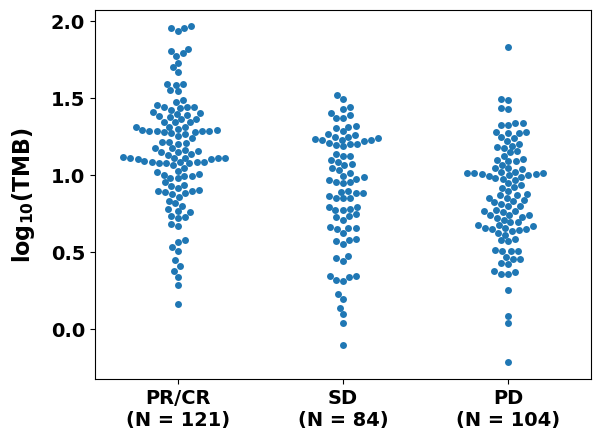

In [40]:
p = sns.swarmplot(data = su2c_merge_master.dropna(subset=['log_TMB']),x = 'Harmonized_Confirmed_BOR_3_Cat',y='log_TMB',order=['CR/PR','SD','PD'])
p.set_xticklabels(['PR/CR\n(N = 121)','SD\n(N = 84)','PD\n(N = 104)'],font='Arial',weight='bold',fontsize=14)
p.set_yticklabels([str(i) for i in p.get_yticks()],font='Arial',weight='bold',fontsize=14)
p.set_ylabel('$\mathregular{log_{10}(TMB)}$',font='Arial',weight='bold',fontsize=16,labelpad=10)
p.set_xlabel('')
p.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

## Driver Survival Curves

In [41]:
su2c_val_harm_dam_pv = pd.read_csv(source_data_path_exome + 'SU2C-MARK_Harmonized_Validated_Damaging_Pivot_v1.txt',sep='\t')

In [42]:
su2c_clinical_dam_merge = su2c_clinical.merge(su2c_clinical_extra,\
        left_on='Harmonized_SU2C_Participant_ID_v2',right_on='Harmonized_SU2C_Participant_ID_v2',how='inner')\
        .merge(su2c_val_harm_dam_pv,left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',
                    right_on='Tumor_Sample_Barcode',how='inner')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

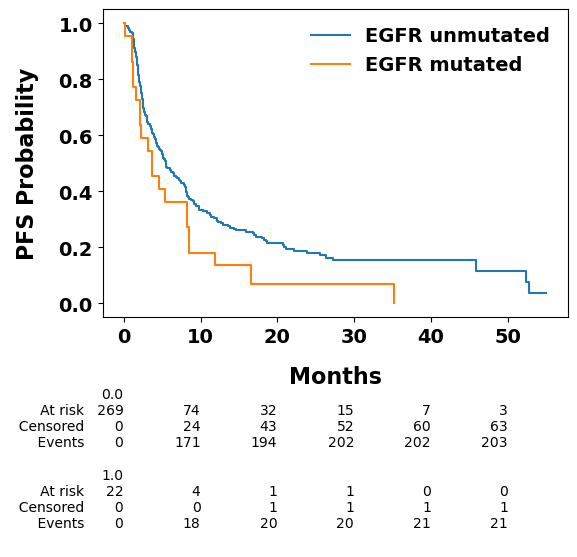

In [43]:
# Plot PFS by Gene

feature_col = 'EGFR'
duration_col = 'Harmonized_PFS_Months'
event_col = 'Harmonized_PFS_Event'

df = su2c_clinical_dam_merge.copy()
df_filt = df[[feature_col,duration_col,event_col]].dropna()
medpfs, ax = survival_curve_pair(df_filt,feature_col,duration_col,event_col)

ax.set_ylabel("PFS Probability",font='Arial',weight='bold',fontsize=16,labelpad = 14)
ax.set_xlabel("Months",font='Arial',weight='bold',fontsize=16,labelpad=14)
ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=14)
ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

L = ax.legend(frameon=False,prop={'size':14,'weight':'bold'})
L.get_texts()[0].set_text(feature_col + " unmutated")
L.get_texts()[1].set_text(feature_col + " mutated")

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

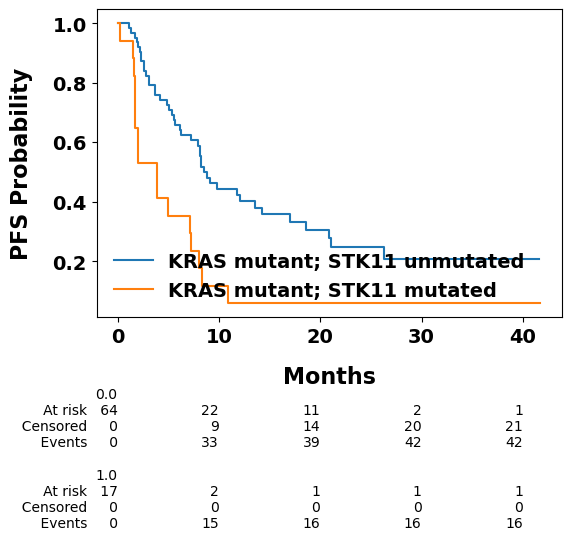

In [44]:
# Plot PFS by Gene

feature_col = 'KRAS/STK11'
duration_col = 'Harmonized_PFS_Months'
event_col = 'Harmonized_PFS_Event'

df = su2c_clinical_dam_merge.copy()
df = df[df['KRAS']==1]
df['KRAS/STK11'] = df['KRAS'] * df['STK11']
df_filt = df[[feature_col,duration_col,event_col]].dropna()
medpfs, ax = survival_curve_pair(df_filt,feature_col,duration_col,event_col)

ax.set_ylabel("PFS Probability",font='Arial',weight='bold',fontsize=16,labelpad = 14)
ax.set_xlabel("Months",font='Arial',weight='bold',fontsize=16,labelpad=14)
ax.set_xticklabels(np.round(ax.get_xticks()),font='Arial',weight='bold',fontsize=14)
ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

L = ax.legend(frameon=False,prop={'size':14,'weight':'bold'})
L.get_texts()[0].set_text("KRAS mutant; STK11 unmutated")
L.get_texts()[1].set_text("KRAS mutant; STK11 mutated")

## Logistic Regression Across Exome Drivers

In [45]:
log_reg_df_mut = log_reg_df.loc[log_reg_df.index.to_series().apply(lambda x: '_MUT' in x)]

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

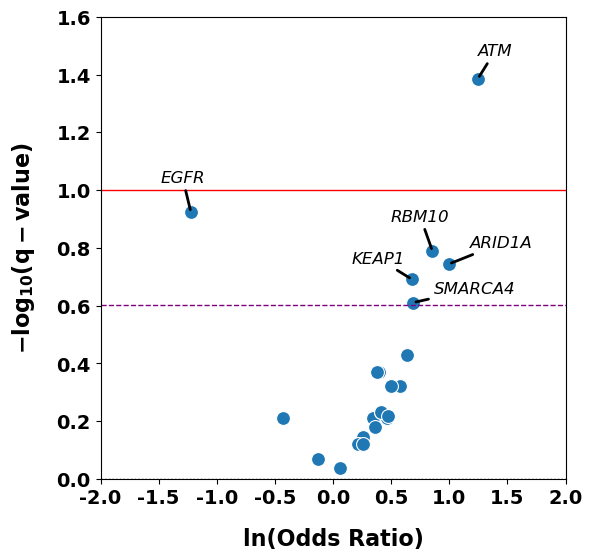

In [46]:
df = log_reg_df_mut
x = df['coeff']
y = df['q_value']

fig,ax = plt.subplots(figsize=(6,6))

ax.axhline(linewidth=1,y=-np.log10(0.1),linestyle='-',c='r')
ax.axhline(linewidth=1,y=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axhline(linewidth=1,y=0,linestyle='dotted',c='k')

sns.scatterplot(x=x,y=-np.log10(y),ax=ax,s=100)
plt.xlim(-2,2)
plt.ylim(0,1.6)

for i in range(0,len(df.index)):
    
    xi = x[i]
    yi = -np.log10(y[i])
    gene = df.index[i].split('_')[0]
    
    if yi>(-np.log10(0.25)):
        if gene == 'ATM':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(0,20),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')
        elif gene == 'ARID1A':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(15,15),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')
        elif gene == 'KEAP1':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(-5,15),textcoords='offset points', va='center',ha='right',\
                        arrowprops=dict(arrowstyle='-',color='k',lw=2),size=12,style='italic')
        elif gene == 'SMARCA4':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(15,10),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',color='k',lw=2),size=12,style='italic')
        elif gene == 'TP53':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(0,25),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',color='k',lw=2),size=12,style='italic')
        elif gene == 'RBM10':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(-30,25),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',color='k',lw=2),size=12,style='italic')
        elif gene == 'EGFR':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(10,25),textcoords='offset points', va='center',ha='right',\
                        arrowprops=dict(arrowstyle='-',color='k',lw=2),size=12,style='italic')


_ = ax.set_xlabel("ln(Odds Ratio)",font='Arial',weight='bold',fontsize=16,labelpad = 14)
_ = ax.set_ylabel("$\mathregular{-log_{10}(q-value)}$",font='Arial',weight='bold',fontsize=16,labelpad=14)
_ = ax.set_xticklabels(np.round(ax.get_xticks()),font='Arial',weight='bold',fontsize=14)
_ = ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)            

ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

## Copy Number and Response

In [47]:
common_peaks_index = np.where(((su2c_cnv_peak.iloc[0:68,9:]>1).sum(axis=1)/309)>0.05)[0]

In [48]:
common_peaks_freq = su2c_cnv_peak_actual_t.columns[common_peaks_index].to_list()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

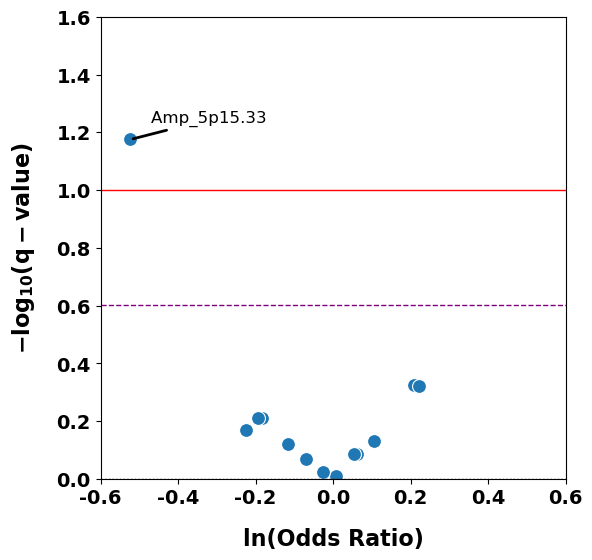

In [49]:
df = log_reg_df.loc[common_peaks_freq]
x = df['coeff']
y = df['q_value']

fig,ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=x,y=-np.log10(y),ax=ax,s=100)
plt.xlim(-0.6,0.6)
plt.ylim(0,1.6)

ax.axhline(linewidth=1,y=-np.log10(0.1),linestyle='-',c='r')
ax.axhline(linewidth=1,y=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axhline(linewidth=1,y=0,linestyle='dotted',c='k')

for i in range(0,len(df.index)):
    
    xi = x[i]
    yi = -np.log10(y[i])
    gene = df.index[i]
    
    if y[i]<1:
        if gene == 'Amp_5p15.33 ':
            plt.annotate(df.index[i],xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(15,15),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12)
            
_ = ax.set_xlabel("ln(Odds Ratio)",font='Arial',weight='bold',fontsize=16,labelpad = 14)
_ = ax.set_ylabel("$\mathregular{-log_{10}(q-value)}$",font='Arial',weight='bold',fontsize=16,labelpad=14)
_ = ax.set_xticklabels(np.round(ax.get_xticks(),1),font='Arial',weight='bold',fontsize=14)
_ = ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)            

## Gene CNVs and Response

In [50]:
common_cnv_gene_freq = su2c_cnv_gene_sig_t.columns[((abs(su2c_cnv_gene_sig_t)>0.9).sum()/309)>0.05].to_list()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

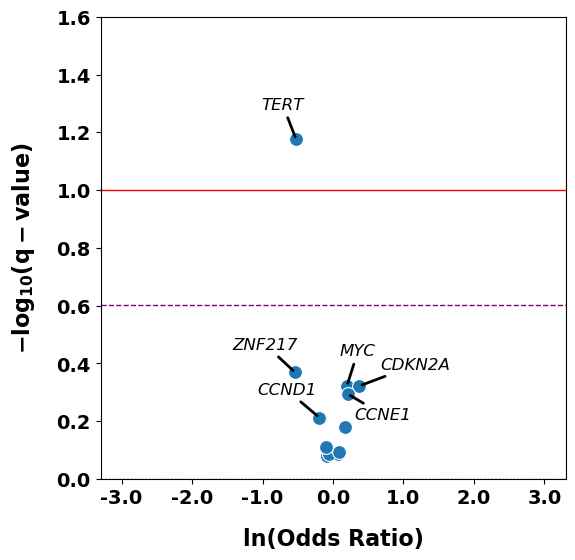

In [51]:
df = log_reg_df.loc[[gene + '_CNV' for gene in common_cnv_gene_freq]]

x = df['coeff']
y = df['q_value']

fig,ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=x,y=-np.log10(y),ax=ax,s=100)
plt.xlim(-3.3,3.3)
plt.ylim(0,1.6)

ax.axhline(linewidth=1,y=-np.log10(0.1),linestyle='-',c='r')
ax.axhline(linewidth=1,y=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axhline(linewidth=1,y=0,linestyle='dotted',c='k')

for i in range(0,len(df.index)):
    
    xi = x[i]
    yi = -np.log10(y[i])
    gene = df.index[i].split('_')[0]
    
    if y[i]<0.3:
        if gene == 'TERT':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(-25,25),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')
    elif gene == 'CCNE1':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(5,-15),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')
    elif gene == 'B2M':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(-30,15),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')    
    elif gene == 'ZNF217':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(-45,20),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')
    elif gene == 'CDKN2A':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(15,15),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')
    elif gene == 'MYC':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(-5,25),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')
    elif gene == 'CCND1':
            plt.annotate(gene,xy=(x[i],-np.log10(y[i])),\
                         xycoords='data',xytext=(-45,20),textcoords='offset points', va='center',ha='left',\
                        arrowprops=dict(arrowstyle='-',lw=2,color='k'),size=12,style='italic')
            
            
_ = ax.set_xlabel("ln(Odds Ratio)",font='Arial',weight='bold',fontsize=16,labelpad = 14)
_ = ax.set_ylabel("$\mathregular{-log_{10}(q-value)}$",font='Arial',weight='bold',fontsize=16,labelpad=14)
_ = ax.set_xticklabels(np.round(ax.get_xticks()),font='Arial',weight='bold',fontsize=14)
_ = ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)

## Signature Totals

In [52]:
sig_cols = ['log_Neoantigens',
       'log_Neoantigens_clonal', 'log_Neoantigens_subclonal',
       'Subclone_count', 'log_Aging_Signature', 'log_Smoking_Signature',
       'log_APOBEC_Signature', 'log_TMB_indel','HLA_LOH_present', 'HLA_hom_present', 'B2M_altered',
            'log_DNA_BCR_burden', 'log_DNA_TCR_burden']

In [53]:
sig_cols_rename = ['Neoantigens', 'Neoantigens clonal',
       'Neoantigens subclonal', 'Subclone count', 'Aging burden', 'Smoking burden',
       'APOBEC burden', 'Indel burden','HLA LOH','HLA homozygosity','B2M alteration','DNA BCR burden',
       'DNA TCR burden']

In [54]:
df_plot = log_reg_df.loc[sig_cols]

In [55]:
df_plot['-log10(q-value)'] = -np.log10(df_plot['q_value'])

In [56]:
df_plot.index = sig_cols_rename

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

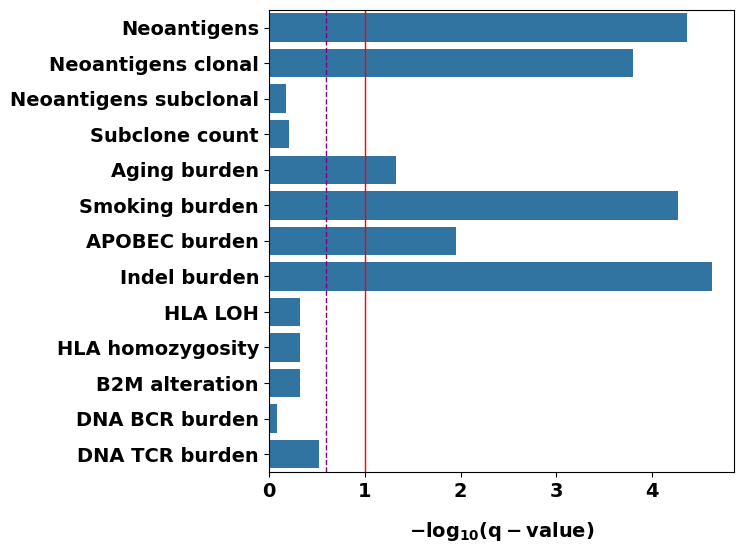

In [57]:
plt.figure(figsize=(6,6))
h = sns.barplot(y=sig_cols_rename,x=df_plot['-log10(q-value)'],orient = 'h')

for item in h.get_yticklabels():
    item.set_font('Arial')
    item.set_fontweight('bold')
    item.set_fontsize(14)
    ax=plt.gca()
    
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')

_ = ax.set_xlabel("$\mathregular{-log_{10}(q-value)}$",font='Arial',weight='bold',fontsize=14,labelpad=14)
_ = ax.set_xticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)

# Expression Analysis

## Immune Cell Subsets

In [58]:
sf_subsets = ['B-cells_y', 'Cytotoxic cells_y', 'DC_y',
       'Exhausted CD8_y', 'Exhausted/HS CD8', 'Lymphocytes',
       'Lymphocytes exhausted/cell cycle', 'Macrophages/Monocytes',
       'Memory T cells', 'Plasma', 'Treg_y']

In [59]:
df_plot = log_reg_df.loc[su2c_is_sf_harm.columns[1:] + '_SF']

In [60]:
df_plot = df_plot.sort_values('coeff',ascending=False)

In [61]:
sf_cols_rename=['Exhausted CD8+ T-cells (G6)',
                'Regulatory T-cells (G7)',
                'Lymphocytes exhausted/cell-cycle (G11)',
                'Exhausted/HS CD8+ T-cells (G9)',
                'Cytotoxic lymphocytes (G8)',
                'B-cells (G1)',                
                'Lymphocytes (G5)',
                'Plasma cells (G2)',
                'Memory T-cells (G10)',
                'Dendritic cells (G4)',
                'Monocytes/Macrophages (G3)']

In [62]:
df_plot['Signed log10(q-value)'] = -np.log10(df_plot['q_value'])*\
    np.sign(df_plot['coeff'])

In [63]:
df_plot = df_plot.sort_values('Signed log10(q-value)',ascending=False)

In [64]:
df_plot['hue'] = np.sign(df_plot["coeff"])

In [65]:
df_plot.index = sf_cols_rename

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

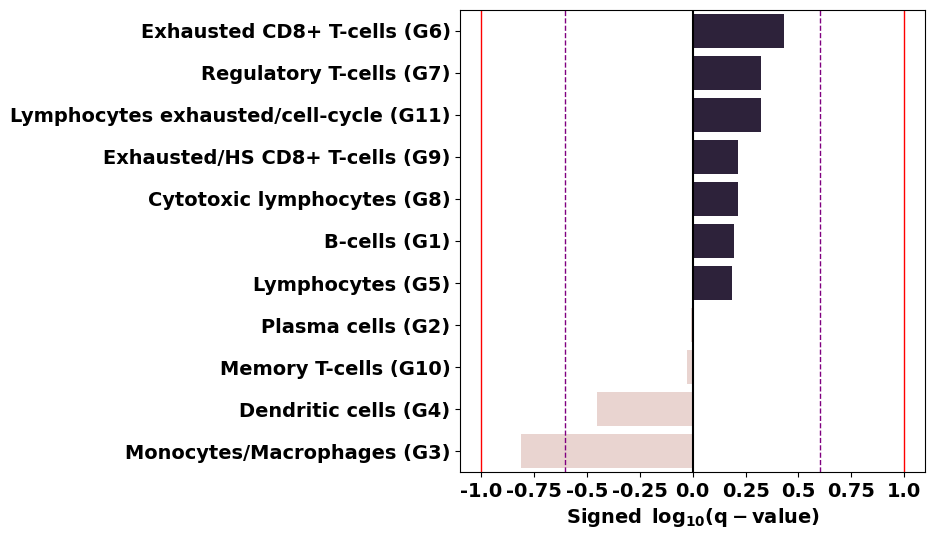

In [66]:
plt.figure(figsize=(6,6))
h = sns.barplot(y=df_plot.index,x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['hue'],dodge=False)

ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]

plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')

plt.ylabel(None)
plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=14,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.ylim(10.5,-0.5)

plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=14)

ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=14)
h.legend_.remove()

## M Cluster Signatures

<Figure size 1400x800 with 0 Axes>

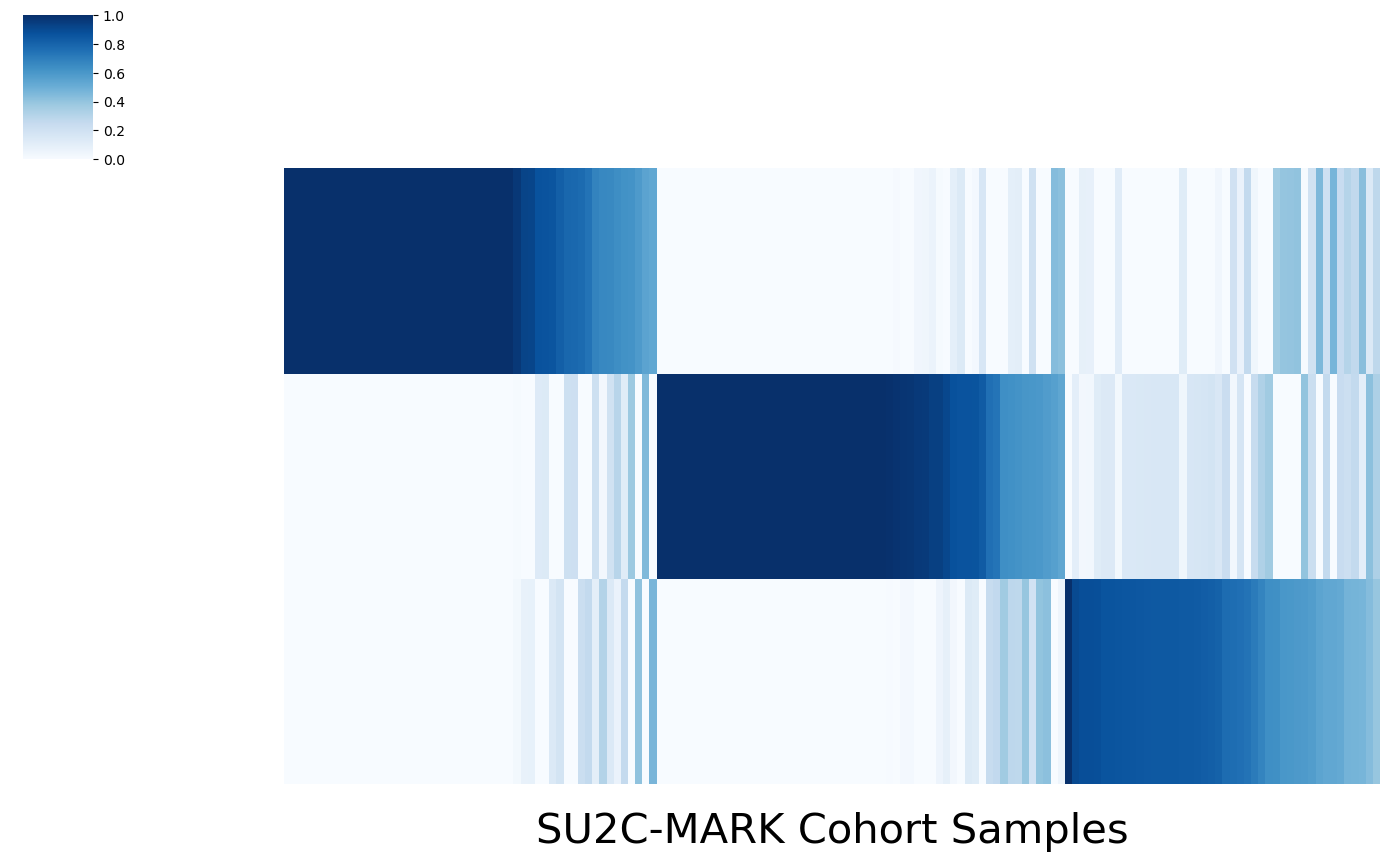

In [67]:
su2c_ssbnmf_harm = su2c_ssbnmf_harm.sort_values(by=['Integrative_cluster'])
su2c_ssbnmf_harm_sorted_I1 = su2c_ssbnmf_harm[su2c_ssbnmf_harm['Integrative_cluster']==1].sort_values(by='I1_norm',\
                                                                ascending=False)
su2c_ssbnmf_harm_sorted_I2 = su2c_ssbnmf_harm[su2c_ssbnmf_harm['Integrative_cluster']==2].sort_values(by='I2_norm',\
                                                                ascending=False)
su2c_ssbnmf_harm_sorted_I3 = su2c_ssbnmf_harm[su2c_ssbnmf_harm['Integrative_cluster']==3].sort_values(by='I3_norm',\
                                                                ascending=False)
su2c_ssbnmf_harm_sorted = pd.concat([su2c_ssbnmf_harm_sorted_I1,su2c_ssbnmf_harm_sorted_I2,\
          su2c_ssbnmf_harm_sorted_I3])
plt.figure(figsize=(14,8))
g = sns.clustermap(su2c_ssbnmf_harm_sorted[['I1_norm','I2_norm','I3_norm']].T,vmin=0,vmax=1,cmap='Blues',\
            yticklabels=False,xticklabels=False,row_cluster=False,col_cluster=False,\
               cbar_kws={'ticks':None,'label':None},figsize=(14,8))
_=g.ax_heatmap.set_xlabel('SU2C-MARK Cohort Samples',fontsize=30,labelpad=20)

## Gene Set Enrichment Results for M Clusters

In [68]:
su2c_tme_gsea_harm['-log10(p-value)'] = -np.log10(su2c_tme_gsea_harm['p-value'])

In [69]:
su2c_tme_gsea_harm_pivot = pd.pivot_table(su2c_tme_gsea_harm[['Gene Set Name','Set','-log10(p-value)']],\
                    index='Set',values='-log10(p-value)',columns='Gene Set Name').fillna(0).T
su2c_tme_gsea_harm_pivot_sorted =su2c_tme_gsea_harm_pivot.sort_values(by=['G1','G2','G3'],ascending=False)

In [70]:
su2c_tme_gsea_harm['Gene Set Name Short'] = su2c_tme_gsea_harm['Gene Set Name'].apply(lambda x: x.replace('HALLMARK_',''))

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

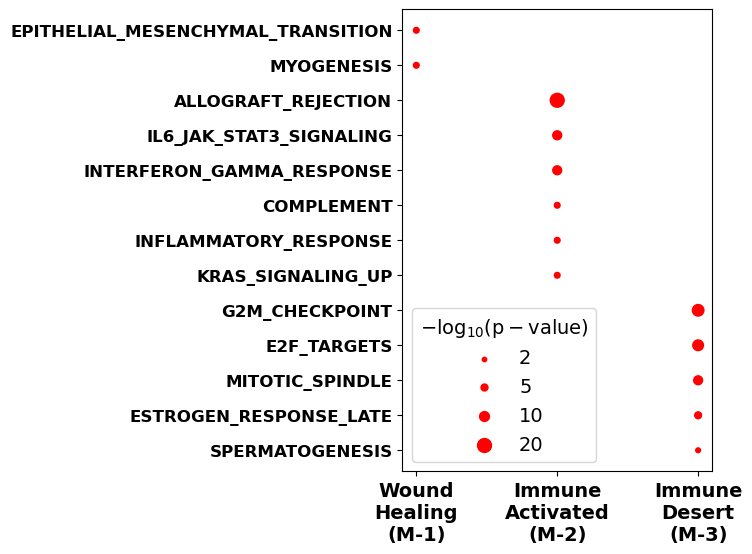

In [71]:
plt.figure(figsize=(4,6))

g = plt.scatter(data = su2c_tme_gsea_harm,x = 'Set',y = 'Gene Set Name Short',\
           color='r',vmin=0,vmax=5,s=su2c_tme_gsea_harm['-log10(p-value)']*5)

plt.gca().invert_yaxis()

ax = plt.gca()
ax.set_xticklabels(['Wound\nHealing\n(M-1)','Immune\nActivated\n(M-2)','Immune\nDesert\n(M-3)'])
plt.ylabel(None)
_ = plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=12,weight='bold')
plt.xlabel(None)
_ = plt.setp(ax.get_xticklabels(),font = 'Arial',fontsize=14,weight='bold')

msizes = [2, 5, 10, 20]
markers = []
for size in msizes:
   markers.append(plt.scatter([],[], s=size*5, label=size, color='r'))

_=plt.legend(handles=markers,title = "$\mathregular{-log_{10}(p-value)}$",title_fontsize=14,fontsize=14,loc='lower left')

## Response Rate by M Cluster

In [72]:
I_cluster_response = su2c_merge_master[['Integrative_cluster','Harmonized_Confirmed_BOR_Bin']]\
    .groupby(by=['Integrative_cluster','Harmonized_Confirmed_BOR_Bin']).size().reset_index().\
    sort_values(['Integrative_cluster','Harmonized_Confirmed_BOR_Bin'])

In [73]:
I_cluster_response['Response']= ['Non-responder','Responder']*3

In [74]:
a = I_cluster_response.pivot_table(index='Integrative_cluster',values=0,columns='Response')
a_norm = a.apply(lambda x: x/x.sum(),axis=1)

In [75]:
tab10 = sns.color_palette('tab10')

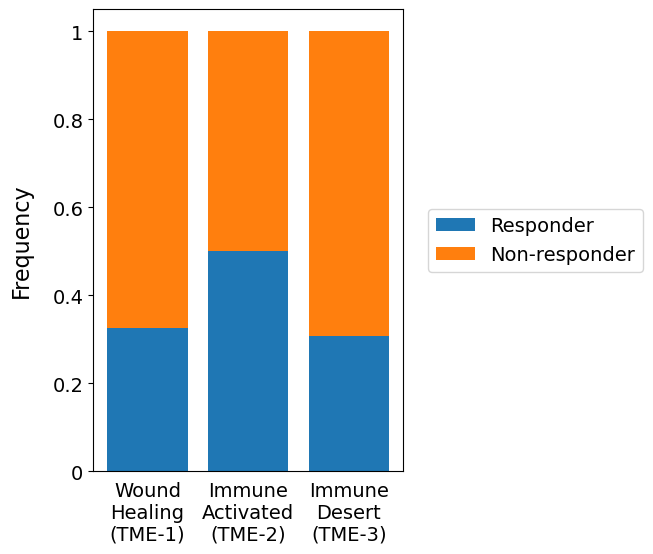

In [76]:
plt.figure(figsize=(4,6))
plt.bar(a_norm.index,a_norm['Responder'],color=tab10[0],label = 'Responder')
plt.bar(a_norm.index,a_norm['Non-responder'],color=tab10[1],bottom = a_norm['Responder'],label='Non-responder')
plt.legend(loc='center left',bbox_to_anchor=(1.05,0.5),ncol=1,fontsize=14)
g = plt.gca()
g.set_xticklabels(['','','Wound\nHealing\n(TME-1)','','Immune\nActivated\n(TME-2)','','Immune\nDesert\n(TME-3)'],fontsize=14)
g.set_yticklabels([0,0.2,0.4,0.6,0.8,1],fontsize=14)
g.tick_params(bottom=False)
_=g.set_ylabel('Frequency',fontsize=16,labelpad = 14)

## Immune Cell Subsets by M Cluster

In [77]:
sf_subsets = [col for col in su2c_merge_master.columns if '_SF' in col][1:]

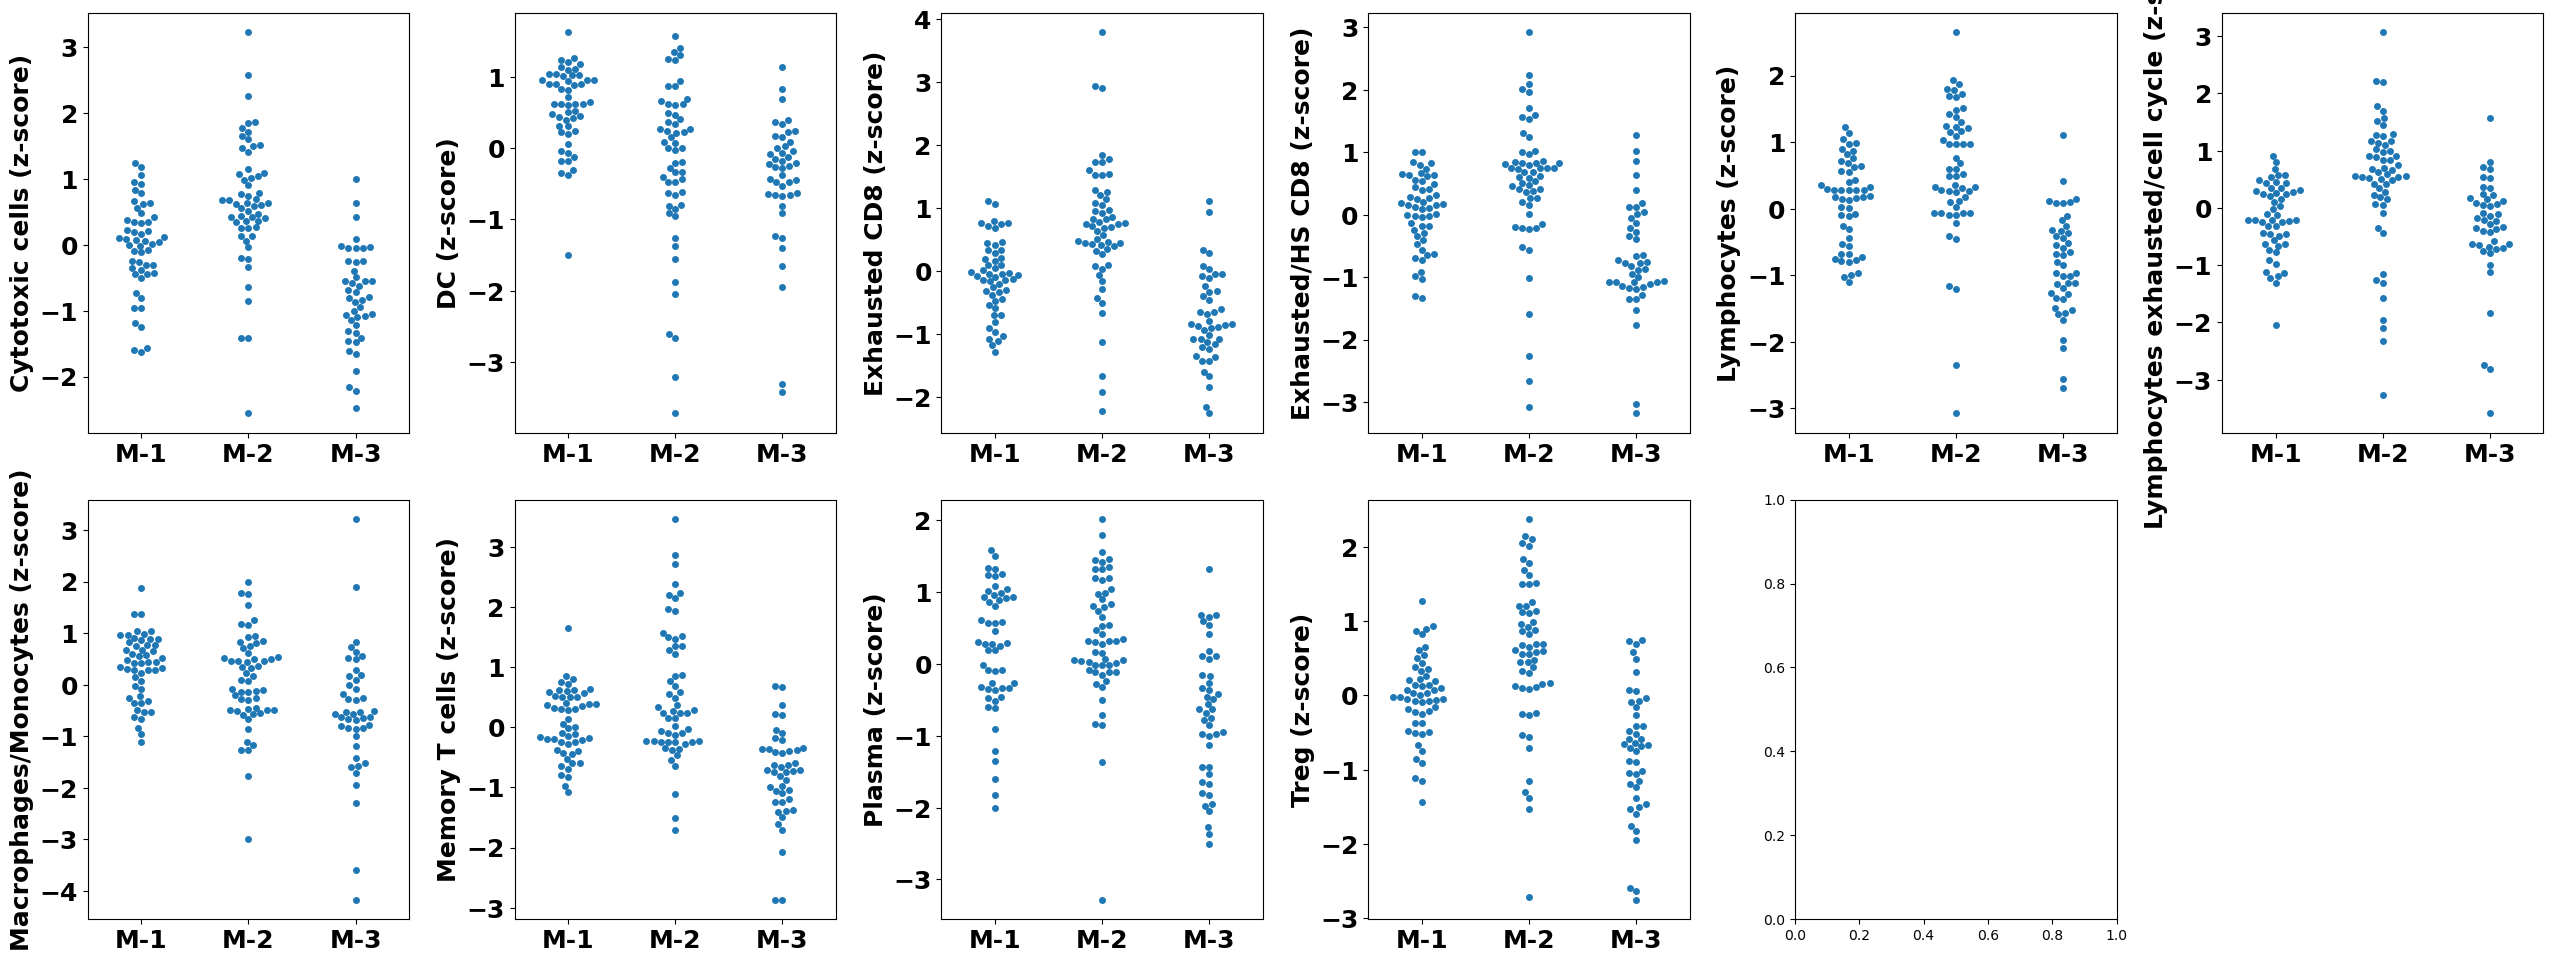

In [78]:
rows = 2
cols = 6
zi_cols = sf_subsets

fig,axs = plt.subplots(rows,cols,figsize=(26,10))

for i in range(0,len(zi_cols)):
    row = int(np.floor(i/cols))
    col = i%cols
    subset = zi_cols[i]
    g = sns.swarmplot(data=su2c_merge_master,x='Integrative_cluster',\
                   y=subset,ax=axs[row,col])
    g.set_xticklabels(['M-1','M-2','M-3'],fontsize=14)
    g.set_ylabel(g.get_ylabel().split('_')[0]+' (z-score)',fontsize=16)
    df = su2c_merge_master[[subset,'Integrative_cluster']].dropna()
    x = df[df.iloc[:,1]==1].iloc[:,0]
    y = df[df.iloc[:,1]==2].iloc[:,0]
    z = df[df.iloc[:,1]==3].iloc[:,0]
    ax = axs[row,col]
    plt.setp(ax.get_xticklabels(), fontsize=18, weight='bold')
    plt.setp(ax.get_yticklabels(), fontsize=18, weight='bold')
    ax.set_xlabel(None)
    ax.set_ylabel(ax.get_ylabel(),fontsize=18,weight='bold')

fig.tight_layout(pad=2)
fig.delaxes(axs[1][5])

## Myeloid Subsets

In [79]:
mphage_subsets = ['hMø1','hMø4', 'hMø5', 'hMø6', 'hMø7', 'hMø8', 'hMø9', 'hMono1', 'hMono2',
       'hMono3', 'hN1', 'hN2', 'hN3', 'hN5', 'hDC1', 'hDC2', 'hDC3', 'hpDC']

In [80]:
df_plot = log_reg_df.loc[[name + '_ZI' for name in mphage_subsets]]

In [81]:
df_plot = df_plot.sort_values('coeff',ascending=False)

In [82]:
df_plot['Signed log10(q-value)'] = -np.log10(df_plot['q_value'])*\
    np.sign(df_plot['coeff'])

In [83]:
df_plot = df_plot.sort_values('Signed log10(q-value)',ascending=False)

In [84]:
df_plot['hue'] = np.sign(df_plot["coeff"])

In [85]:
df_plot.index = [name.split('_')[0] for name in df_plot.index]

In [86]:
df_plot = df_plot.loc[['hMono2','hMono1','hMono3','hMø1', 'hMø9', 'hMø6', 'hMø4','hMø5','hMø8','hMø7','hN2','hN1',  'hN5',  'hN3','hDC2', 'hDC1',  'hpDC', 
       'hDC3']]

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

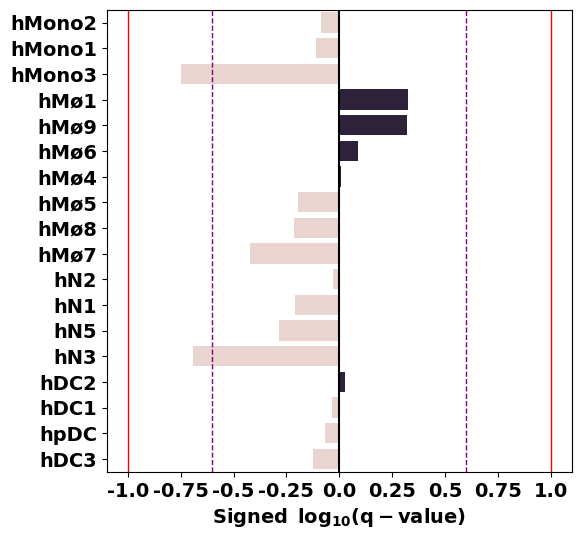

In [87]:
plt.figure(figsize=(6,6))
h = sns.barplot(y=df_plot.index,x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['hue'],dodge=False)

ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]

plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')

plt.ylabel(None)
plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=14,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.ylim(17.5,-0.5)

plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=14)
ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=14)
h.legend_.remove()

## Myeloid Subsets by M Cluster

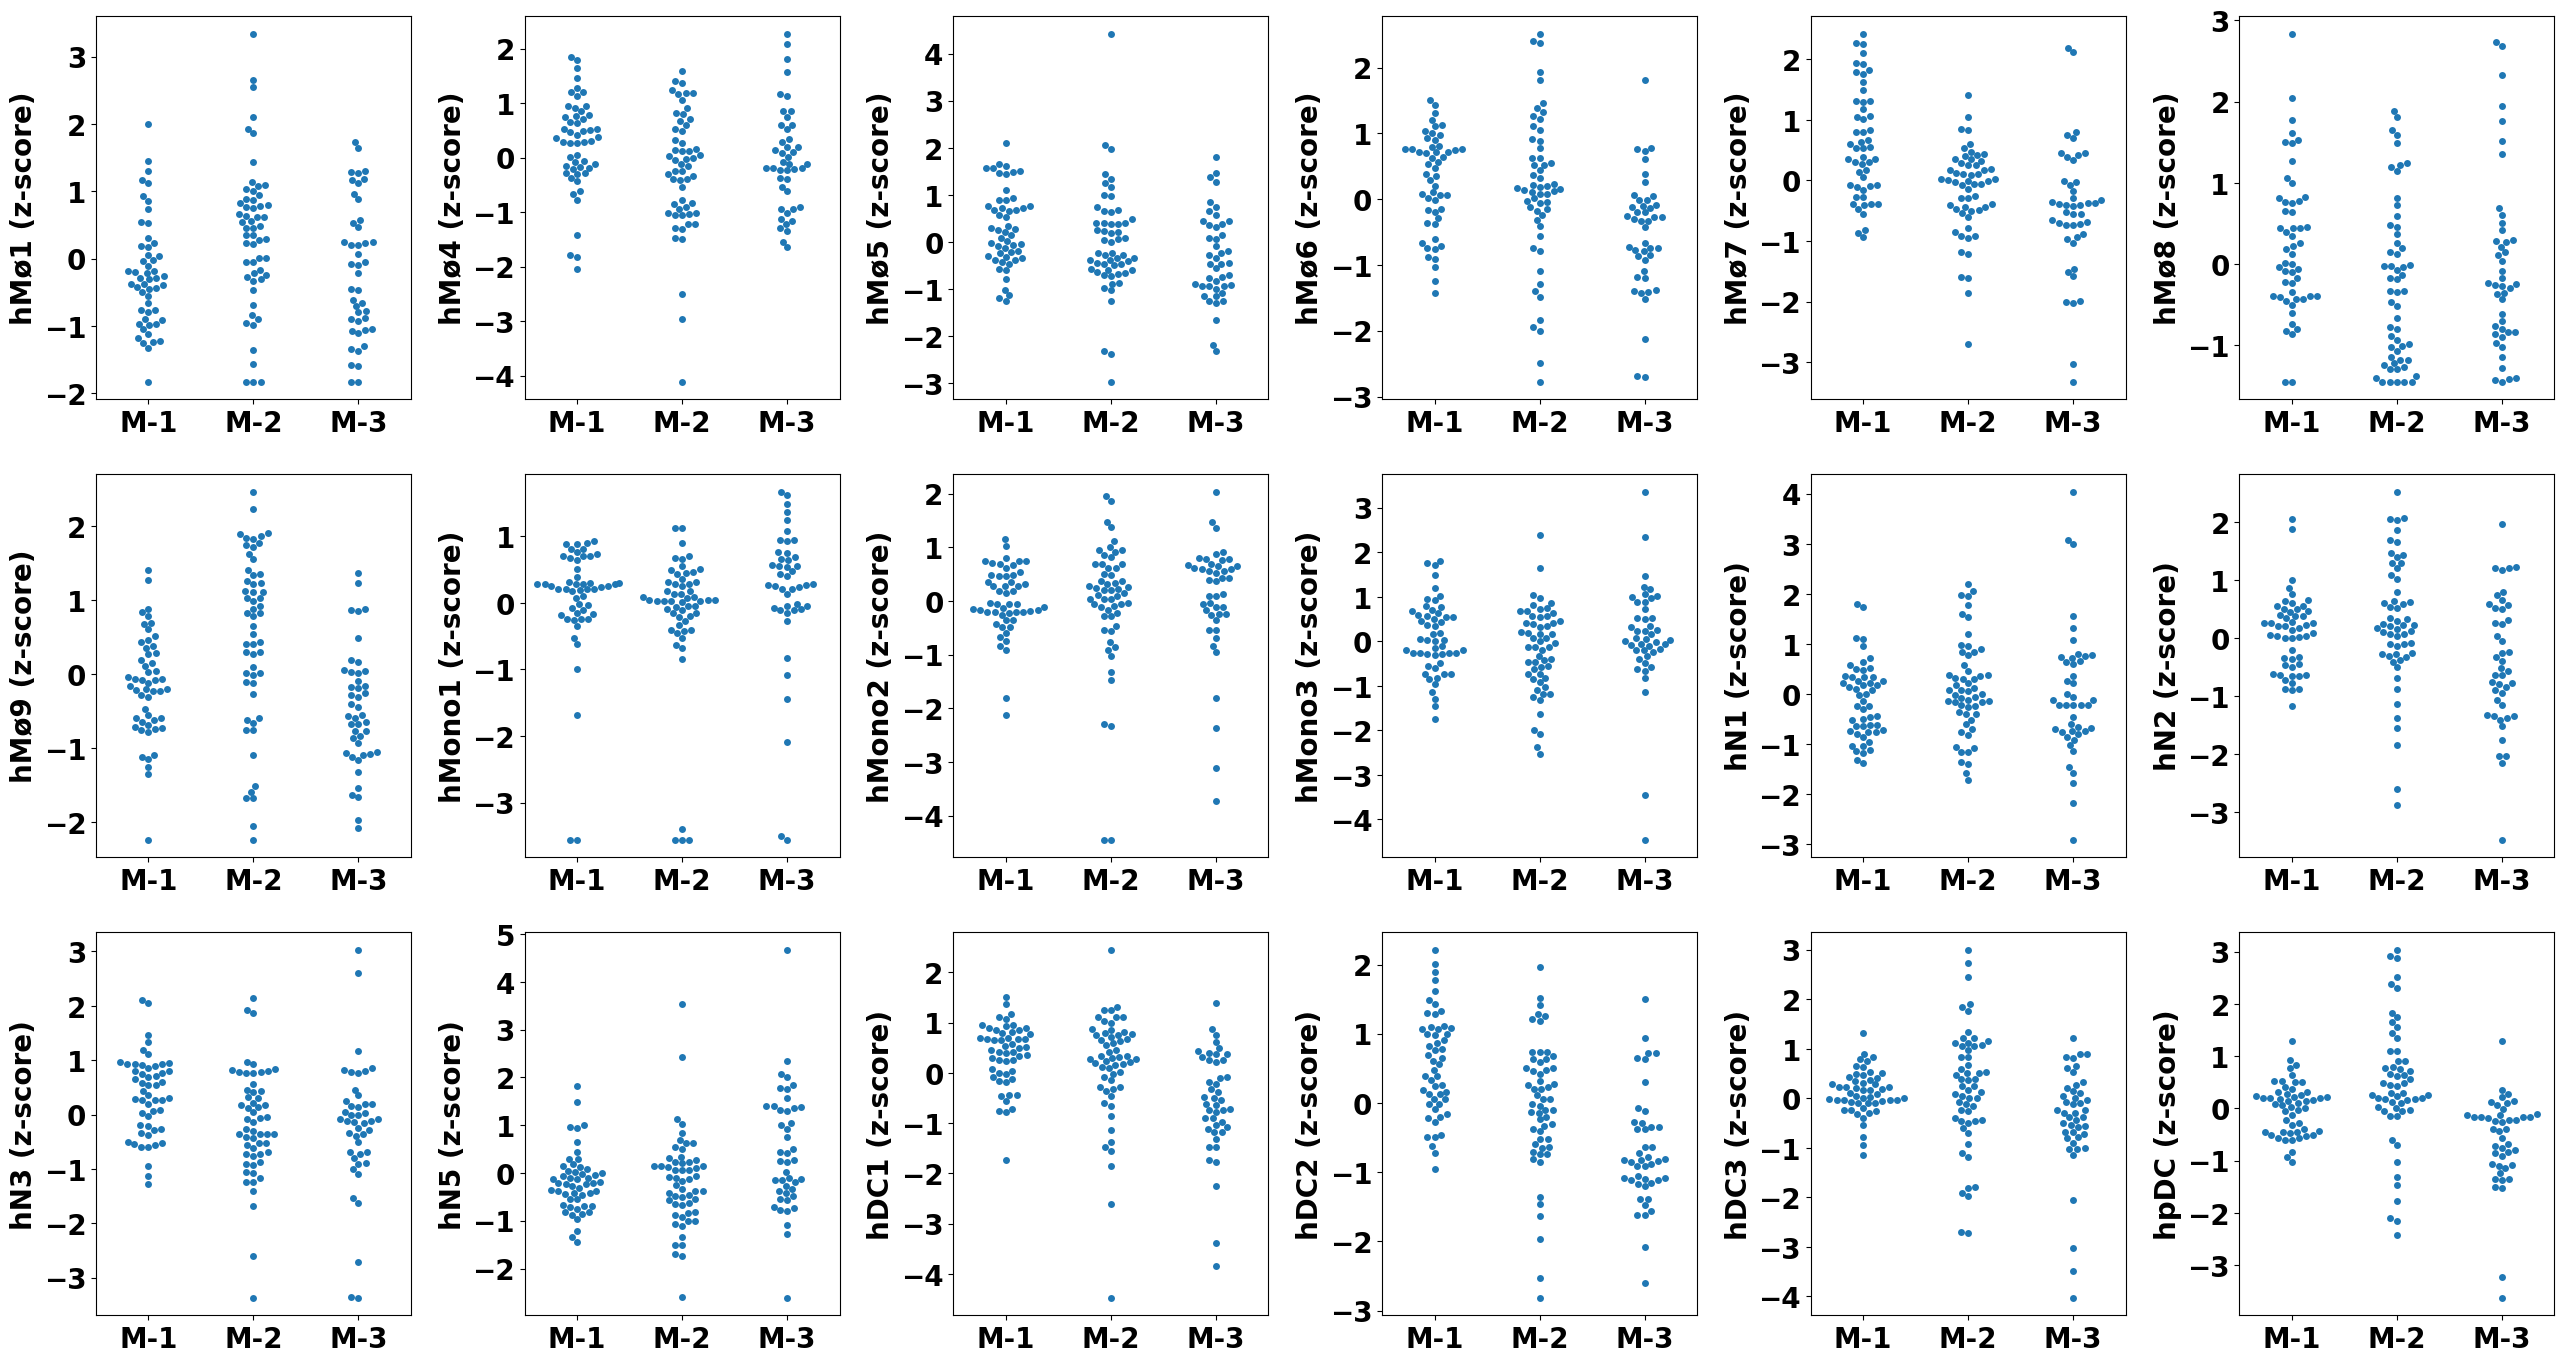

In [88]:
rows = 3
cols = 6
zi_cols = [col +'_ZI' for col in mphage_subsets]

fig,axs = plt.subplots(rows,cols,figsize=(26,14))

for i in range(0,len(zi_cols)):
    row = int(np.floor(i/cols))
    col = i%cols
    subset = zi_cols[i]
    
    g = sns.swarmplot(data=su2c_merge_master,x='Integrative_cluster',\
                   y=subset,ax=axs[row,col])
    g.set_xticklabels(['M-1','M-2','M-3'],fontsize=18)
    g.set_ylabel(g.get_ylabel().split('_')[0]+' (z-score)',fontsize=18)
    
    df = su2c_merge_master[[subset,'Integrative_cluster']].dropna()
    x = df[df.iloc[:,1]==1].iloc[:,0]
    y = df[df.iloc[:,1]==2].iloc[:,0]
    z = df[df.iloc[:,1]==3].iloc[:,0]
    
    ax = axs[row,col]
    plt.setp(ax.get_xticklabels(), fontsize=20, weight='bold')
    plt.setp(ax.get_yticklabels(), fontsize=20, weight='bold')
    ax.set_xlabel(None)
    ax.set_ylabel(ax.get_ylabel(),fontsize=20,weight='bold')
    
fig.tight_layout(pad=2)

## TI Clusters

In [89]:
df_plot = log_reg_df.loc[['T1_norm','T2_norm','T3_norm','T4_norm']]

In [90]:
df_plot = df_plot.sort_values('coeff',ascending=False)

In [91]:
df_plot['Signed log10(q-value)'] = -np.log10(df_plot['q_value'])*\
    np.sign(df_plot['coeff'])

In [92]:
df_plot = df_plot.sort_values('Signed log10(q-value)',ascending=False)

In [93]:
df_plot['hue'] = np.sign(df_plot["coeff"])

In [94]:
df_plot.index = ['TI-1','TI-2','TI-3','TI-4']

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

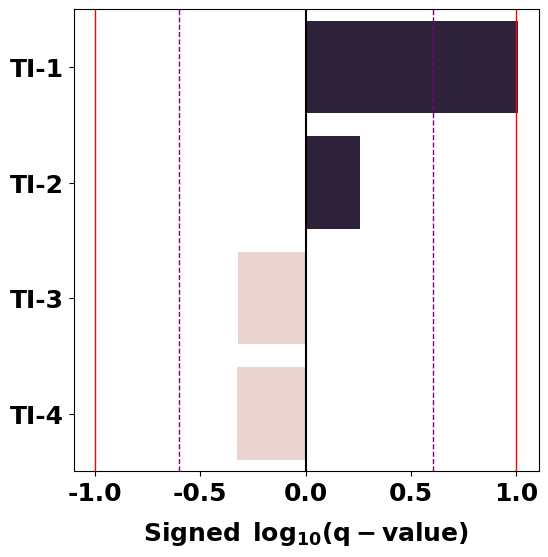

In [95]:
plt.figure(figsize=(6,6))
h = sns.barplot(y=df_plot.index,x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['hue'],dodge=False)

ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]

plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')

plt.ylabel(None)
plt.xticks([-1,-0.5,0,0.5,1])
plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=18,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=18)
plt.ylim(3.5,-0.5)
            
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=18,labelpad=10)

ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=18)
h.legend_.remove()

## M Clusters vs TI Clusters

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

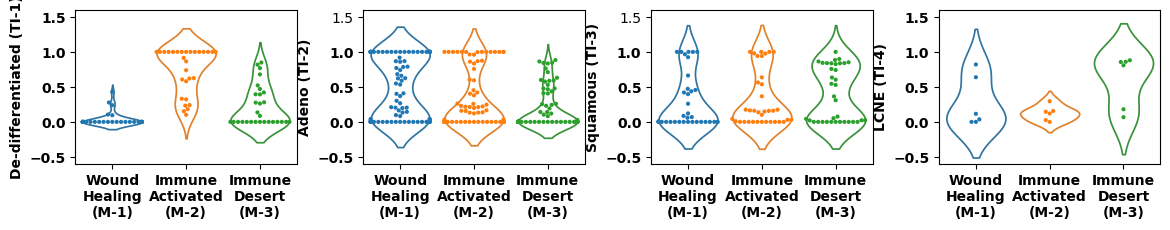

In [96]:
fig,ax = plt.subplots(1,4,figsize=(14,2))

ylabels = ['De-differentiated (TI-1)','Adeno (TI-2)','Squamous (TI-3)','LCNE (TI-4)']
xlabels = ['Wound\nHealing\n(M-1)','Immune\nActivated\n(M-2)','Immune\nDesert\n(M-3)']
for tc in [1,2,3,4]:
    axis = sns.violinplot(data = su2c_merge_master[su2c_merge_master['Tumor_cluster']==tc][['I1_norm','I2_norm','I3_norm']]\
                          ,ax=ax[tc-1],inner=None)
    
    for violin in axis.collections:
        violin.set_edgecolor(violin.get_facecolor())
        violin.set_facecolor((0,0,0,0))

    g = sns.swarmplot(data = su2c_merge_master[su2c_merge_master['Tumor_cluster']==tc][['I1_norm','I2_norm','I3_norm']],\
                   s=3,ax=ax[tc-1])

    plt.setp(ax[tc-1].get_yticklabels(), font = 'Arial',fontsize=10,weight='bold')
    plt.setp(ax[tc-1].get_xticklabels(), fontsize=14)
    ax[tc-1].set_ylim(-0.6,1.6)
    ax[tc-1].set_ylabel(ylabels[tc-1],font='Arial',weight='bold',fontsize=10,\
                        rotation=90)
            
    ax[tc-1].set_xticklabels(xlabels,font='Arial',weight='bold',fontsize=10)
    #plt.yticks([0,0.5,1],[0.0,0.5,1.0])

plt.subplots_adjust(wspace=0.3)

## TI-1 vs M-2

Text(0, 0.5, 'Immune Activated (M-2)')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

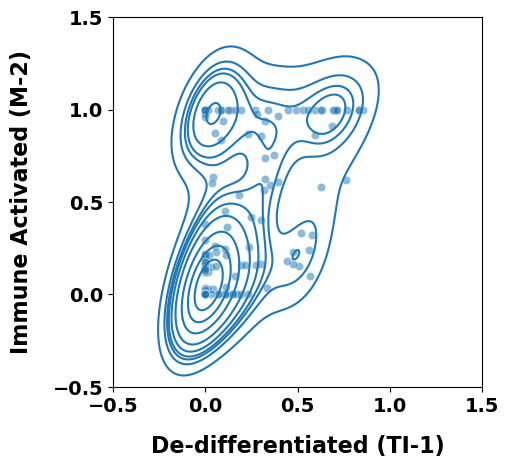

In [97]:
_ = sns.kdeplot(data = su2c_merge_master, x='T1_norm',y='I2_norm')
_ = sns.scatterplot(data = su2c_merge_master, x='T1_norm',y='I2_norm',alpha = 0.5)

plt.axis('square')
plt.xlim(-0.5,1.5)
plt.ylim(-.5,1.5)

ax = plt.gca()

plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=14,weight='bold')
plt.setp(ax.get_xticklabels(), font = 'Arial',fontsize=14,weight='bold')

ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))

ax.set_xlabel("De-differentiated (TI-1)",font='Arial',weight='bold',fontsize=16,labelpad=14)
ax.set_ylabel("Immune Activated (M-2)",font='Arial',weight='bold',fontsize=16,labelpad=14)

## Response Rate Grid

In [98]:
a = su2c_merge_master[(su2c_merge_master['T1_norm']<0.5) & (su2c_merge_master['I2_norm']<0.5)]['Harmonized_Confirmed_BOR_Bin'].mean()

In [99]:
b = su2c_merge_master[(su2c_merge_master['T1_norm']>=0.5) & (su2c_merge_master['I2_norm']<0.5)]['Harmonized_Confirmed_BOR_Bin'].mean()

In [100]:
c = su2c_merge_master[(su2c_merge_master['T1_norm']<0.5) & (su2c_merge_master['I2_norm']>=0.5)]['Harmonized_Confirmed_BOR_Bin'].mean()

In [101]:
d = su2c_merge_master[(su2c_merge_master['T1_norm']>=0.5) & (su2c_merge_master['I2_norm']>=0.5)]['Harmonized_Confirmed_BOR_Bin'].mean()

In [102]:
rr_df = pd.DataFrame([[c,d],[a,b]],index=['TME-2','TME-2/3/4'],columns=['TI-2/3/4','TI-1'])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

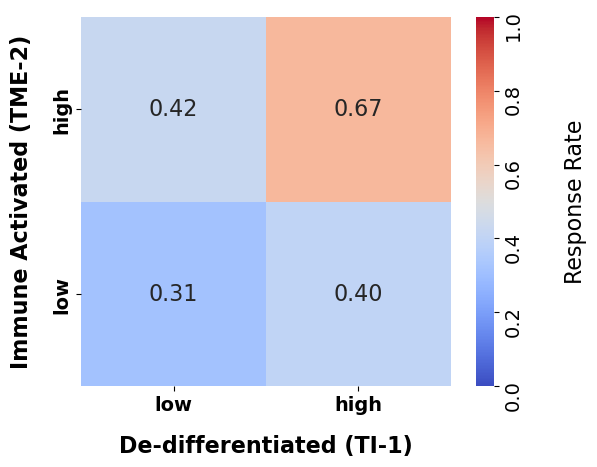

In [103]:
k = sns.heatmap(rr_df,cmap='coolwarm',center=0.5,vmin=0,vmax=1,square='equal',annot=True,fmt="0.2f",annot_kws={"font":'Arial',"size":16})

ax = plt.gca()

plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=14,weight='bold')
plt.setp(ax.get_xticklabels(), font = 'Arial',fontsize=14,weight='bold')

k.set_xticklabels(labels=['low','high'], va='center')
k.set_yticklabels(labels=['high','low'], va='center')

ax.tick_params(axis='x', which='major', pad=10)

_ = ax.set_xlabel("De-differentiated (TI-1)",font='Arial',weight='bold',fontsize=16,labelpad=14)
_ = ax.set_ylabel("Immune Activated (TME-2)",font='Arial',weight='bold',fontsize=16,labelpad=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14,rotation=90)
_ = cbar.ax.set_ylabel("Response Rate",rotation=90,labelpad=30,font='Arial',fontsize=16)

# Heatmap

In [104]:
su2c_limma_harm_names = su2c_limma_harm.copy()

In [105]:
su2c_limma_harm

,Unnamed: 0,logFC,AveExpr,t,P.Value,adj.P.Val,B,ensembl_gene_id_version,hgnc_symbol,median_log2tpm,gexp_gt1_percent,gexp_gt1_cat
0,1,-0.403370,1.093088,-1.635074,0.104315,0.403476,-4.315271,ENSG00000187634.11,SAMD11,1.117063,0.785124,50-80%
1,2,0.088979,5.565879,1.021167,0.308964,0.632204,-5.437019,ENSG00000188976.10,NOC2L,5.311830,0.983471,80-100%
2,3,-0.019629,3.103165,-0.153923,0.877896,0.954957,-5.669993,ENSG00000187961.13,KLHL17,3.266475,0.983471,80-100%
3,4,0.194845,2.217655,0.922449,0.357906,0.669481,-5.190195,ENSG00000187583.10,PLEKHN1,2.603013,0.958678,80-100%
4,5,0.110187,-1.277853,0.368140,0.713334,0.883703,-5.027598,ENSG00000187642.9,PERM1,0.504215,0.512397,50-80%
...,...,...,...,...,...,...,...,...,...,...,...,...
15919,15920,-0.030611,-2.134503,-0.058044,0.953797,0.983985,-4.991965,ENSG00000212907.2,MT-ND4L,0.986818,0.694215,50-80%
15920,15921,0.100938,3.287562,0.304060,0.761541,0.906471,-5.662744,ENSG00000198886.2,MT-ND4,3.966421,0.983471,80-100%
15921,15922,0.092029,2.675790,0.267282,0.789652,0.917426,-5.589396,ENSG00000198786.2,MT-ND5,2.860538,0.975207,80-100%
15922,15923,0.118278,0.748120,0.317369,0.751444,0.902208,-5.280615,ENSG00000198695.2,MT-ND6,2.683016,0.966942,80-100%


In [106]:
su2c_limma_harm_names.index = su2c_limma_harm.apply(lambda x: x['ensembl_gene_id_version'] + ':' + str(x['hgnc_symbol']),axis=1)

In [107]:
su2c_rna_harm_log = su2c_rna_harm.set_index(['Name','Description']).apply(lambda x: np.log(x+1))

In [108]:
su2c_rna_harm_log.index = su2c_rna_harm.apply(lambda x: x['Name'] + ':' + x['Description'],axis=1)

In [109]:
su2c_rna_harm_log_z = su2c_rna_harm_log.T.apply(scp.zscore).T

In [110]:
top_cutoff = 20

In [111]:
su2c_limma_harm_names['signed_log10p'] = np.sign(su2c_limma_harm_names['logFC'])*(-np.log10(su2c_limma_harm_names['P.Value']))

In [112]:
l_top_up = su2c_limma_harm_names.sort_values('signed_log10p').tail(int(top_cutoff/2)).index.to_list()
l_top_dn = su2c_limma_harm_names.sort_values('signed_log10p').head(int(top_cutoff/2)).index.to_list()
l_top_all = l_top_up+l_top_dn

In [113]:
l_top_up_clean =[gene for gene in l_top_up if 'nan' not in gene]
l_top_dn_clean =[gene for gene in l_top_dn if 'nan' not in gene]
l_top_all_clean =[gene for gene in l_top_all if 'nan' not in gene]

In [114]:
su2c_rna_harm_log_z_all = su2c_rna_harm_log_z.loc[l_top_all_clean]

In [115]:
su2c_rna_harm_log_merge = su2c_rna_harm_log_z_all.T.merge(su2c_merge_master,left_index=True,right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')

In [116]:
su2c_rna_harm_log_merge.set_index('Harmonized_SU2C_Participant_ID_v2',inplace=True)

In [117]:
q_near_sig_list = ['PDL1_TPS', 'ARID1A_MUT', 'ATM_MUT', 'EGFR_MUT', 'KEAP1_MUT',
       'RBM10_MUT', 'SMARCA4_MUT', 'Amp_5p15.33 ', 'TERT_CNV', 'log_TMB',
       'log_TMB_clonal', 'log_TMB_indel','log_Neoantigens', 'log_Neoantigens_clonal',
       'log_Aging_Signature', 'log_Smoking_Signature', 'log_APOBEC_Signature', 'T1_norm',
       'I2_norm', 'Macrophages/Monocytes_SF', 'hMono3_ZI','hN3_ZI']

In [118]:
q_sig_list = ['PDL1_TPS', 'ATM_MUT', 'Amp_5p15.33 ', 'TERT_CNV', 'log_TMB',
       'log_TMB_clonal', 'log_Neoantigens', 'log_Neoantigens_clonal',
       'log_S1-SBS80_P', 'log_S3-SBS4_P', 'log_S5-SBS13_P', 'T1_norm']

In [119]:
select_cols = ['hMono3_ZI', 'hN3_ZI',
       'Macrophages/Monocytes_SF', 'Adenosine (Corvus)_HM',
       'ENSG00000204131.9:NHSL2', 'EMT2 (PMID: 27321955)_HM',
       'TGF-B (Mariathasan Nature 2018)_HM', 'ENSG00000143554.13:SLC27A3',
       'NFAT/NR4A1 family T cell dysfunction_HM', 'ENSG00000116991.10:SIPA1L2',
       'ENSG00000158321.15:AUTS2', 'ENSG00000152284.4:TCF7L1',
       'ENSG00000196504.15:PRPF40A',
       'Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM',
       'ENSG00000240065.7:PSMB9',
       'Antigen processing machinery (PMID: 27855702)_HM', 'IFNG_HM',
       'ENSG00000092010.14:PSME1', 'ENSG00000100911.15:PSME2', 'PDL1_TPS',
       'T1_norm', 'I2_norm','log_APOBEC_Signature', 'log_Aging_Signature', 'log_TMB_indel',
       'log_Smoking_Signature', 'log_Neoantigens', 'log_Neoantigens_clonal',
       'log_TMB', 'log_TMB_clonal', 'EGFR_MUT', 'Amp_5p15.33 ', 'TERT_CNV',
       'KEAP1_MUT', 'ENSG00000128564.6:VGF', 'ATM_MUT', 'SMARCA4_MUT',
       'ARID1A_MUT', 'RBM10_MUT']

In [120]:
su2c_heatmap = su2c_rna_harm_log_merge[select_cols].corr().fillna(0)

In [121]:
su2c_heatmap_renamed = su2c_heatmap.copy()

In [122]:
su2c_rename_dict = {'hMono3_ZI':'hMono3 (Zilionas et al.)', 
                    'hN3_ZI':'hN3 (Zilionas et al.)',
       'Macrophages/Monocytes_SF':r'M$\phi$\Monocyte (Sade-Feldman et al.)', 
        'Adenosine (Corvus)_HM':'A2AR (Willingham et al.)',
       'ENSG00000204131.9:NHSL2':'$\it{NHSL2}$ Expression',
        'EMT2 (PMID: 27321955)_HM':'EMT (Hedegaard et al.)',
       'TGF-B (Mariathasan Nature 2018)_HM':'TGF-B (Mariathasan et al.)',
        'ENSG00000143554.13:SLC27A3':'$\it{SLC27A3}$ Expression',
       'NFAT/NR4A1 family T cell dysfunction_HM':'NR4A1 (Chen et al.)',
        'ENSG00000116991.10:SIPA1L2':'$\it{SIPA1L2}$ Expression',
       'ENSG00000158321.15:AUTS2':'$\it{AUTS2}$ Expression',
        'ENSG00000152284.4:TCF7L1':'$\it{TCF7L1}$ Expression',
       'ENSG00000196504.15:PRPF40A':'$\it{PRPF40A}$ Expression',
       'Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM':'T cell–inflamed (Ayers et al.)',
       'ENSG00000240065.7:PSMB9':'$\it{PSMB9}$ Expression',
       'Antigen processing machinery (PMID: 27855702)_HM':'MHC Class I (Senbabaoglu et al.)',
        'IFNG_HM':'IFNG Signature (Gao et al.)',
       'ENSG00000092010.14:PSME1':'$\it{PSME1}$ Expression',
        'ENSG00000100911.15:PSME2':'$\it{PSME2}$ Expression', 
        'PDL1_TPS':'PDL1 TPS',
       'T1_norm':'De-differentiated (TI-1)',
        'I2_norm':'Immune Activated (M-2)',
        'log_APOBEC_Signature':'APOBEC burden',
        'log_Aging_Signature':'Aging burden',
        'log_TMB_indel':'TMB indel',
       'log_Smoking_Signature':'Smoking burden',
        'log_Neoantigens':'Neoantigens', 
        'log_Neoantigens_clonal':'Neoantigens clonal',
       'log_TMB':'TMB', 
        'log_TMB_clonal':'TMB clonal',
        'EGFR_MUT':'$\it{EGFR}$ Mutation', 
        'Amp_5p15.33 ':'5p15.33 Amplification',
        'TERT_CNV':'$\it{TERT}$ Amplification',
       'KEAP1_MUT':'$\it{KEAP1}$ Mutation',
        'ENSG00000128564.6:VGF':'$\it{VGF}$ Expression',
        'ATM_MUT':'$\it{ATM}$ Mutation',
        'SMARCA4_MUT':'$\it{SMARCA4}$ Mutation',
       'ARID1A_MUT':'$\it{ARID1A}$ Mutation',
        'RBM10_MUT':'$\it{RBM10}$ Mutation'}

In [123]:
su2c_heatmap_renamed.rename(index=su2c_rename_dict,columns=su2c_rename_dict,inplace=True)

In [124]:
su2c_rename_dict

{'hMono3_ZI': 'hMono3 (Zilionas et al.)',
 'hN3_ZI': 'hN3 (Zilionas et al.)',
 'Macrophages/Monocytes_SF': 'M$\\phi$\\Monocyte (Sade-Feldman et al.)',
 'Adenosine (Corvus)_HM': 'A2AR (Willingham et al.)',
 'ENSG00000204131.9:NHSL2': '$\\it{NHSL2}$ Expression',
 'EMT2 (PMID: 27321955)_HM': 'EMT (Hedegaard et al.)',
 'TGF-B (Mariathasan Nature 2018)_HM': 'TGF-B (Mariathasan et al.)',
 'ENSG00000143554.13:SLC27A3': '$\\it{SLC27A3}$ Expression',
 'NFAT/NR4A1 family T cell dysfunction_HM': 'NR4A1 (Chen et al.)',
 'ENSG00000116991.10:SIPA1L2': '$\\it{SIPA1L2}$ Expression',
 'ENSG00000158321.15:AUTS2': '$\\it{AUTS2}$ Expression',
 'ENSG00000152284.4:TCF7L1': '$\\it{TCF7L1}$ Expression',
 'ENSG00000196504.15:PRPF40A': '$\\it{PRPF40A}$ Expression',
 'Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM': 'T cell–inflamed (Ayers et al.)',
 'ENSG00000240065.7:PSMB9': '$\\it{PSMB9}$ Expression',
 'Antigen processing machinery (PMID: 27855702)_HM': 'MHC Class I (Senbabaoglu et al.)',
 'IFNG_HM'

In [155]:
su2c_heatmap_renamed.shape

(39, 39)

In [126]:
favorable_list = ['$\it{PRPF40A}$ Expression', 'T cell–inflamed (Ayers et al.)',
       '$\it{PSMB9}$ Expression', 'MHC Class I (Senbabaoglu et al.)',
       'IFNG Signature (Gao et al.)', '$\it{PSME1}$ Expression',
       '$\it{PSME2}$ Expression', 'PDL1 TPS', 'De-differentiated (TI-1)',
       'Immune Activated (M-2)', 'APOBEC burden', 'Aging burden', 'TMB indel',
       'Smoking burden', 'Neoantigens', 'Neoantigens clonal', 'TMB',
       'TMB clonal', '$\it{KEAP1}$ Mutation',
       '$\it{VGF}$ Expression', '$\it{ATM}$ Mutation',
       '$\it{SMARCA4}$ Mutation', '$\it{ARID1A}$ Mutation',
       '$\it{RBM10}$ Mutation']

In [127]:
palette_sig = sns.diverging_palette(150,10,n=8)

In [128]:
df_corr = su2c_heatmap_renamed
palette = sns.color_palette()
palette
color_dict = {}
for i in range(0,len(df_corr.columns)):
    if i<12:
        color_dict[df_corr.columns[i]] = palette[4]
    elif i<22:
        color_dict[df_corr.columns[i]] = palette[1]
    elif i<30:
        color_dict[df_corr.columns[i]] = palette[0]
    else:
        color_dict[df_corr.columns[i]] = palette[6]
# Convert the dictionary into a Series
color_rows_heatmap = pd.Series(color_dict,name='Correlation Cluster')

In [129]:
df_corr = su2c_heatmap_renamed
color_dict = {}
for i in range(0,len(df_corr.index)):
    if df_corr.index[i] in favorable_list:
        color_dict[df_corr.index[i]] = palette_sig[0]
    else:
        color_dict[df_corr.index[i]] = palette_sig[7]

    # Convert the dictionary into a Series
color_sig_heatmap = pd.Series(color_dict,name='Correlation Cluster')

In [130]:
lut = dict(zip(['Positive','Negative'], \
               [palette_sig[0],palette_sig[7]]))

In [157]:
su2c_heatmap_renamed.

,hMono3 (Zilionas et al.),hN3 (Zilionas et al.),M$\phi$\Monocyte (Sade-Feldman et al.),A2AR (Willingham et al.),$\it{NHSL2}$ Expression,EMT (Hedegaard et al.),TGF-B (Mariathasan et al.),$\it{SLC27A3}$ Expression,NR4A1 (Chen et al.),$\it{SIPA1L2}$ Expression,...,TMB clonal,$\it{EGFR}$ Mutation,5p15.33 Amplification,$\it{TERT}$ Amplification,$\it{KEAP1}$ Mutation,$\it{VGF}$ Expression,$\it{ATM}$ Mutation,$\it{SMARCA4}$ Mutation,$\it{ARID1A}$ Mutation,$\it{RBM10}$ Mutation
hMono3 (Zilionas et al.),1.000000,0.414755,0.591500,0.547851,0.325832,0.345976,0.388611,0.289295,0.209728,0.459800,...,0.055549,-0.163053,-0.098012,-0.098042,0.082061,0.001530,-0.062995,0.058393,-0.092758,0.093282
hN3 (Zilionas et al.),0.414755,1.000000,0.613334,0.537313,0.553093,0.483617,0.440045,0.420156,0.349565,0.455448,...,0.106257,-0.157357,0.036010,0.036054,-0.091725,0.022297,-0.054619,0.067422,0.129820,0.432098
M$\phi$\Monocyte (Sade-Feldman et al.),0.591500,0.613334,1.000000,0.586319,0.419337,0.493627,0.399166,0.421503,0.254655,0.229082,...,0.084453,-0.208865,-0.234917,-0.234951,-0.096350,-0.141125,-0.247086,0.102193,0.069440,0.346394
A2AR (Willingham et al.),0.547851,0.537313,0.586319,1.000000,0.301164,0.494338,0.523383,0.166409,0.480759,0.335784,...,-0.043195,-0.311604,-0.235521,-0.235513,-0.028858,-0.073847,-0.277528,0.153338,0.115057,0.210525
$\it{NHSL2}$ Expression,0.325832,0.553093,0.419337,0.301164,1.000000,0.706420,0.633385,0.411844,0.470870,0.547508,...,-0.005063,0.043507,-0.114028,-0.114041,-0.099720,-0.136272,-0.020633,0.220538,0.028827,0.278255
EMT (Hedegaard et al.),0.345976,0.483617,0.493627,0.494338,0.706420,1.000000,0.759318,0.530756,0.569920,0.477333,...,-0.167395,-0.010941,-0.172895,-0.172904,-0.147393,-0.106423,-0.198795,0.185851,-0.072940,-0.073544
TGF-B (Mariathasan et al.),0.388611,0.440045,0.399166,0.523383,0.633385,0.759318,1.000000,0.334259,0.431342,0.409502,...,-0.104732,-0.072641,-0.196423,-0.196410,-0.061801,-0.088558,-0.138036,0.258780,0.016523,-0.152561
$\it{SLC27A3}$ Expression,0.289295,0.420156,0.421503,0.166409,0.411844,0.530756,0.334259,1.000000,0.356094,0.399318,...,-0.199164,0.038412,0.091317,0.091203,0.090115,0.078657,0.313585,0.009852,-0.024339,-0.007161
NR4A1 (Chen et al.),0.209728,0.349565,0.254655,0.480759,0.470870,0.569920,0.431342,0.356094,1.000000,0.387275,...,-0.140788,-0.170031,-0.082166,-0.082132,0.148276,0.086229,-0.024694,0.075214,0.064345,0.331538
$\it{SIPA1L2}$ Expression,0.459800,0.455448,0.229082,0.335784,0.547508,0.477333,0.409502,0.399318,0.387275,1.000000,...,-0.009428,0.066288,0.133003,0.132926,0.095657,-0.057595,0.260358,0.084671,-0.116157,0.034155


<Figure size 1000x1000 with 0 Axes>

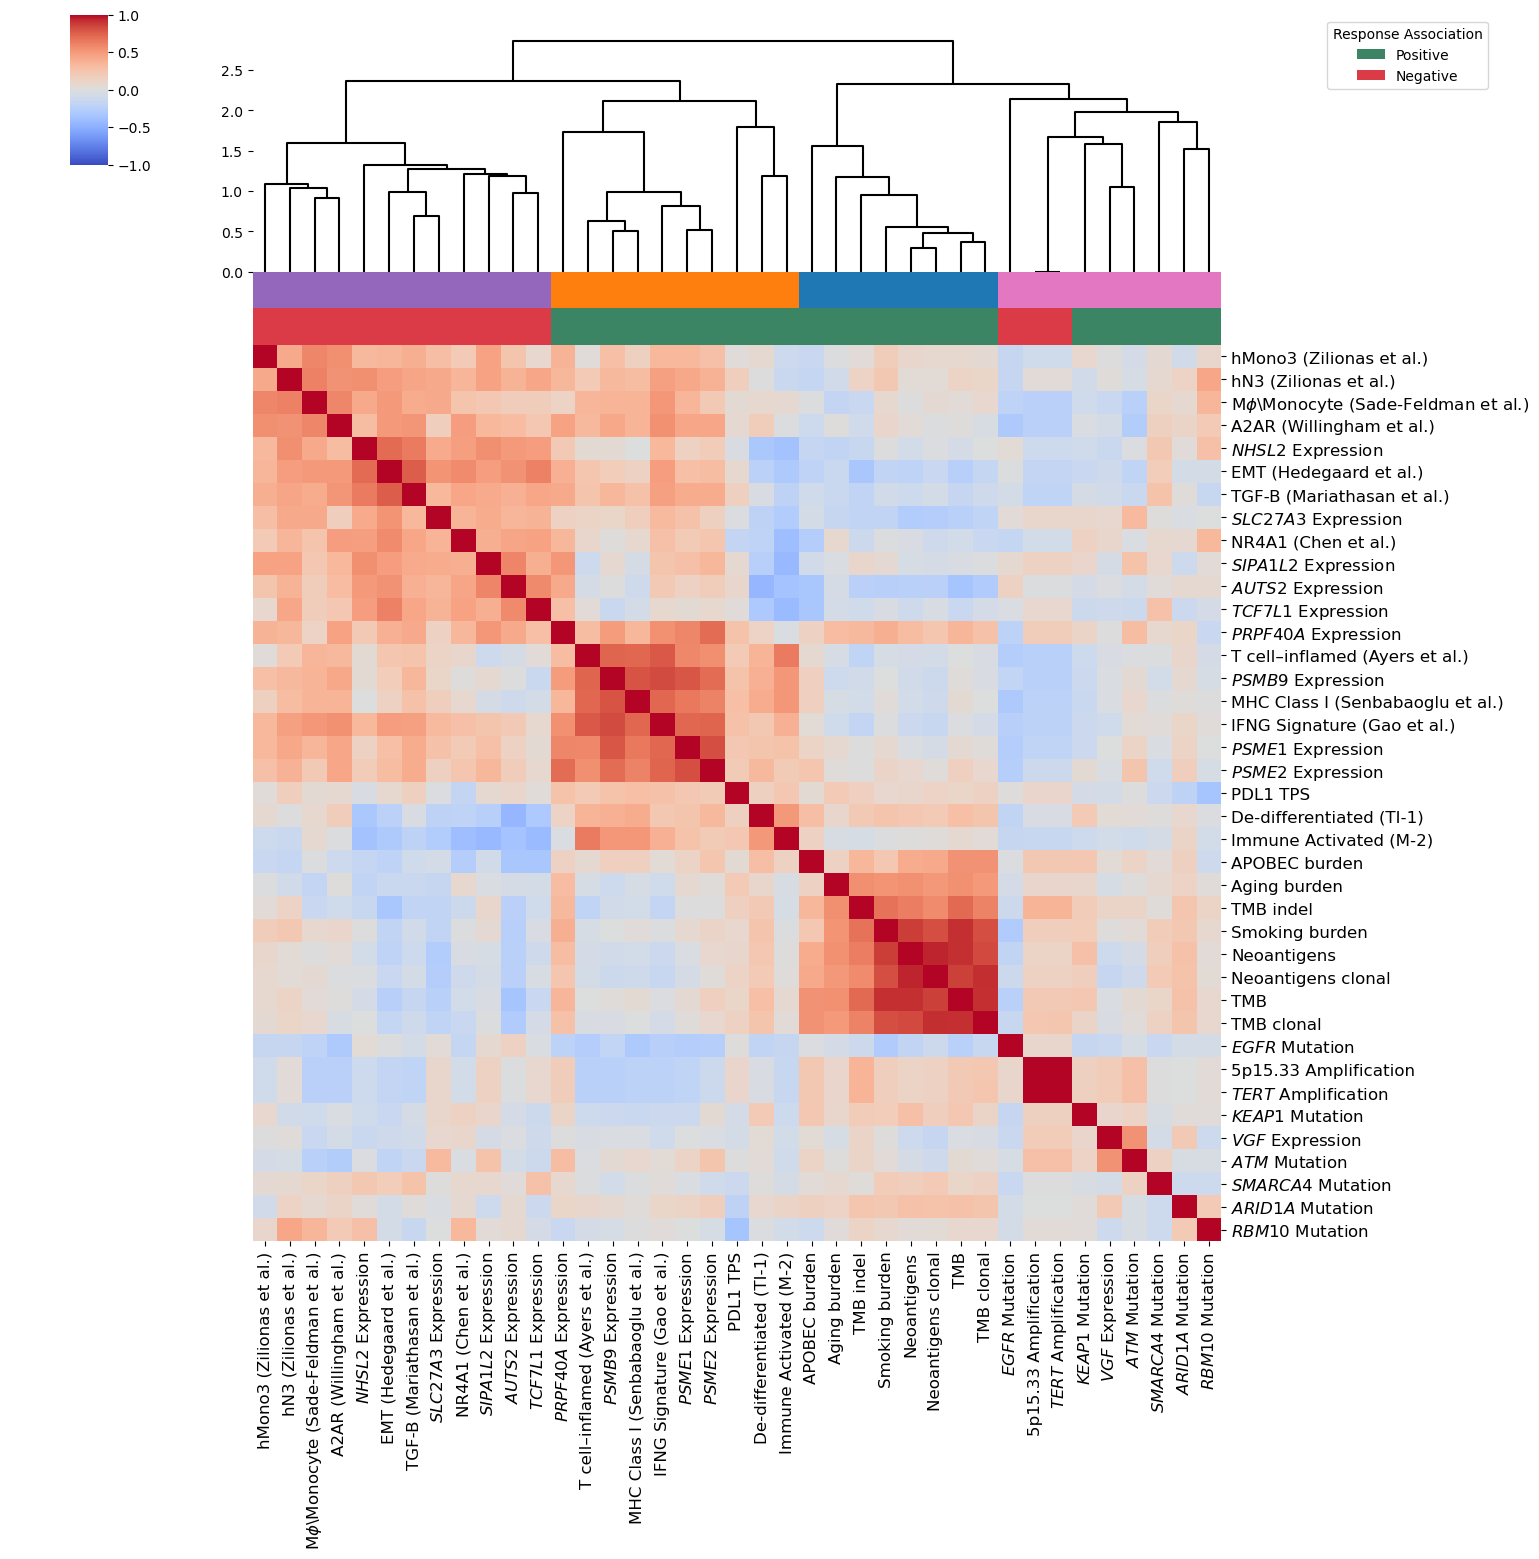

In [131]:
og = sns.clustermap(su2c_heatmap_renamed)
og.fig.clf()
g = sns.clustermap(su2c_heatmap_renamed,vmin=-1,vmax=1,cmap='coolwarm',\
              yticklabels=True,xticklabels=True,figsize=(15,15),\
                   col_colors=[color_rows_heatmap,color_sig_heatmap],row_cluster=False,col_cluster=False)
axx = g.ax_col_dendrogram.axes
axx.clear()

link = og.dendrogram_col.linkage
link[[36,35]] = link[[35,36]]
dendrogram(link, 
           color_threshold=0, 
           ax=axx,
           #truncate_mode='lastp',
           orientation='top',
           link_color_func=lambda x: 'k'
          );

g.ax_cbar.set_position((0.05, .9, .025, .1))
handles = [mpatches.Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Response Association',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')
_ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 12)
_ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 12)

g.ax_heatmap.yaxis.set_label_position('left')


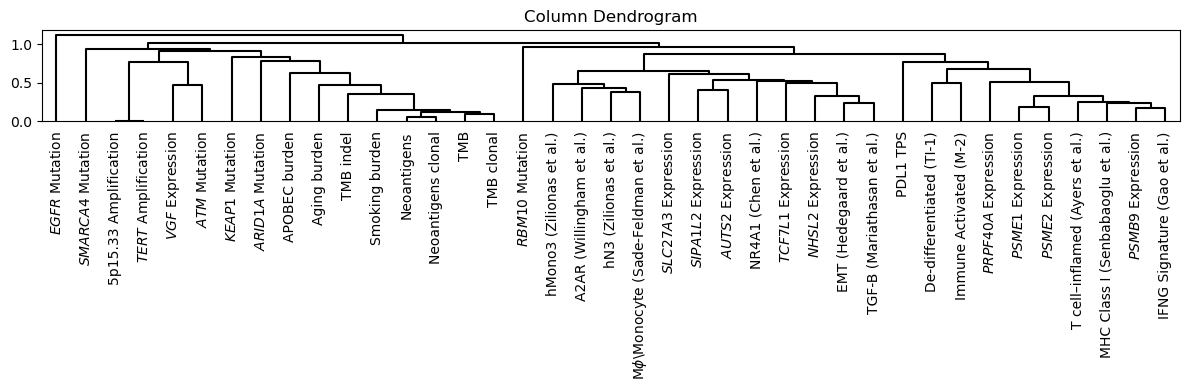

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# su2c_heatmap_renamed: DataFrame (20x20), là correlation matrix

# 1) Convert correlation -> distance
# distance = 1 - correlation (để correlation cao => distance nhỏ)
dist = 1 - su2c_heatmap_renamed.values

# 2) distance matrix phải là condensed form cho linkage
dist_condensed = squareform(dist, checks=False)

# 3) Linkage (giống seaborn thường dùng average)
Z = linkage(dist_condensed, method="average")

# 4) Plot dendrogram
plt.figure(figsize=(12, 4))
dendrogram(
    Z,
    labels=su2c_heatmap_renamed.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0,
    link_color_func=lambda k: "k",  # tất cả nhánh màu đen giống notebook
)
plt.title("Column Dendrogram")
plt.tight_layout()
plt.show()

# Survival Curves

## Biomarker Subsets

In [132]:
interaction_list_tmb = ['hMono3_ZI','Macrophages/Monocytes_SF','T1_norm', 'I2_norm','log_TMB_indel',
                              'TERT_CNV','ATM_MUT']
interaction_list_pdl1 = ['hMono3_ZI','Macrophages/Monocytes_SF','T1_norm', 'I2_norm','log_TMB','log_TMB_indel',
                              'TERT_CNV','ATM_MUT']

In [133]:
ls_high_tmb = []

for feature in interaction_list_tmb:
    
    feature_col = feature

    duration_col = 'Harmonized_PFS_Months'
    event_col = 'Harmonized_PFS_Event'

    df = su2c_merge_master[su2c_merge_master['log_TMB']>np.log10(331/33)]

    df_filt = df[[feature_col,duration_col,event_col]].dropna()
    
    if feature_col in ['log_TMB','log_TMB_indel','T1_norm','I2_norm']:
        med = df[feature_col].median()
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>med)
    else:
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>0)
    
    durations = df_filt[duration_col]
    events = df_filt[event_col]
    groups = df_filt[feature_col].astype('category').cat.codes

    results = multivariate_logrank_test(durations,groups,events)

    df_filt_low = df_filt[df_filt[feature_col]==0]
    df_filt_high = df_filt[df_filt[feature_col]==1]

    kmf_exp = KaplanMeierFitter()
    med_pfs_low = kmf_exp.fit(df_filt_low[duration_col],df_filt_low[event_col]).median_survival_time_
    med_pfs_high = kmf_exp.fit(df_filt_high[duration_col],df_filt_high[event_col]).median_survival_time_
    
    ls_high_tmb.append([feature,results.p_value,-np.log10(results.p_value),results.test_statistic,med_pfs_low,med_pfs_high])

In [134]:
df_high_tmb = pd.DataFrame(ls_high_tmb,columns=['feature','p_value','-log10(p_value)','test_stat','med_pfs_low','med_pfs_high'])

In [135]:
ls_pdl1_high = []

for feature in interaction_list_pdl1:
    
    feature_col = feature

    duration_col = 'Harmonized_PFS_Months'
    event_col = 'Harmonized_PFS_Event'

    df = su2c_merge_master[su2c_merge_master['PDL1_TPS']>=0.5]

    df_filt = df[[feature_col,duration_col,event_col]].dropna()

    if feature_col in ['log_TMB','log_TMB_indel','T1_norm','I2_norm']:
        med = df[feature_col].median()
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>med)
    else:
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>0)
    
    durations = df_filt[duration_col]
    events = df_filt[event_col]
    groups = df_filt[feature_col].astype('category').cat.codes

    results = multivariate_logrank_test(durations,groups,events)

    df_filt_low = df_filt[df_filt[feature_col]==0]
    df_filt_high = df_filt[df_filt[feature_col]==1]

    kmf_exp = KaplanMeierFitter()
    med_pfs_low = kmf_exp.fit(df_filt_low[duration_col],df_filt_low[event_col]).median_survival_time_
    med_pfs_high = kmf_exp.fit(df_filt_high[duration_col],df_filt_high[event_col]).median_survival_time_
    
    ls_pdl1_high.append([feature,results.p_value,-np.log10(results.p_value),results.test_statistic,med_pfs_low,med_pfs_high])

In [136]:
df_pdl1_high = pd.DataFrame(ls_pdl1_high,columns=['feature','p_value','-log10(p_value)','test_stat','med_pfs_low','med_pfs_high'])

In [137]:
ls_pdl1_low = []

for feature in interaction_list_pdl1:

    feature_col = feature

    duration_col = 'Harmonized_PFS_Months'
    event_col = 'Harmonized_PFS_Event'

    df = su2c_merge_master[su2c_merge_master['PDL1_TPS']<=0.01]

    df_filt = df[[feature_col,duration_col,event_col]].dropna()

    if feature_col in ['log_TMB','log_TMB_indel','T1_norm','I2_norm']:
        med = df[feature_col].median()
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>med)
    else:
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>0)
    
    durations = df_filt[duration_col]
    events = df_filt[event_col]
    groups = df_filt[feature_col].astype('category').cat.codes

    results = multivariate_logrank_test(durations,groups,events)

    df_filt_low = df_filt[df_filt[feature_col]==0]
    df_filt_high = df_filt[df_filt[feature_col]==1]

    kmf_exp = KaplanMeierFitter()
    med_pfs_low = kmf_exp.fit(df_filt_low[duration_col],df_filt_low[event_col]).median_survival_time_
    med_pfs_high = kmf_exp.fit(df_filt_high[duration_col],df_filt_high[event_col]).median_survival_time_
    
    ls_pdl1_low.append([feature,results.p_value,-np.log10(results.p_value),results.test_statistic,med_pfs_low,med_pfs_high])

In [138]:
df_pdl1_low = pd.DataFrame(ls_pdl1_low,columns=['feature','p_value','-log10(p_value)','test_stat','med_pfs_low','med_pfs_high'])

In [139]:
df_high_tmb['subset'] = 'High TMB'
df_pdl1_high['subset'] = 'High PDL1'
df_pdl1_low['subset'] = 'Low PDL1'

In [140]:
df_subset = pd.concat([df_high_tmb,df_pdl1_high,df_pdl1_low]).dropna(subset=['p_value'])

In [141]:
df_subset['q'] = multi.multipletests(df_subset['p_value'],method='fdr_bh')[1]

In [142]:
df_subset['-log10(q-values)'] = -np.log10(df_subset['q'])

In [143]:
df_subset['favorable'] = df_subset['med_pfs_low']<df_subset['med_pfs_high']

In [144]:
df_subset = df_subset.reset_index().drop('index',axis=1)

In [145]:
for row in range(0,len(df_subset.index)):
    if df_subset.loc[row,'favorable']:
        df_subset.loc[row,'Signed log10(q-value)'] = df_subset.loc[row,'-log10(q-values)']
    else:
        df_subset.loc[row,'Signed log10(q-value)'] = -1*df_subset.loc[row,'-log10(q-values)']

In [146]:
df_subset['cluster'] = '0'
for i in range(0,len(df_subset.index)):
    if df_subset['feature'][i] in ['hMono3_ZI','Macrophages/Monocytes_SF']:
        df_subset.iloc[i,-1] = '1'
    elif df_subset['feature'][i] in ['PDL1_TPS','T1_norm','I2_norm']:
        df_subset.iloc[i,-1] = '2'
    elif df_subset['feature'][i] in ['log_TMB','log_TMB_indel']:
        df_subset.iloc[i,-1] = '3'
    else:
        df_subset.iloc[i,-1] = '4'

In [147]:
df_subset = df_subset.sort_values(by=['subset','cluster'])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

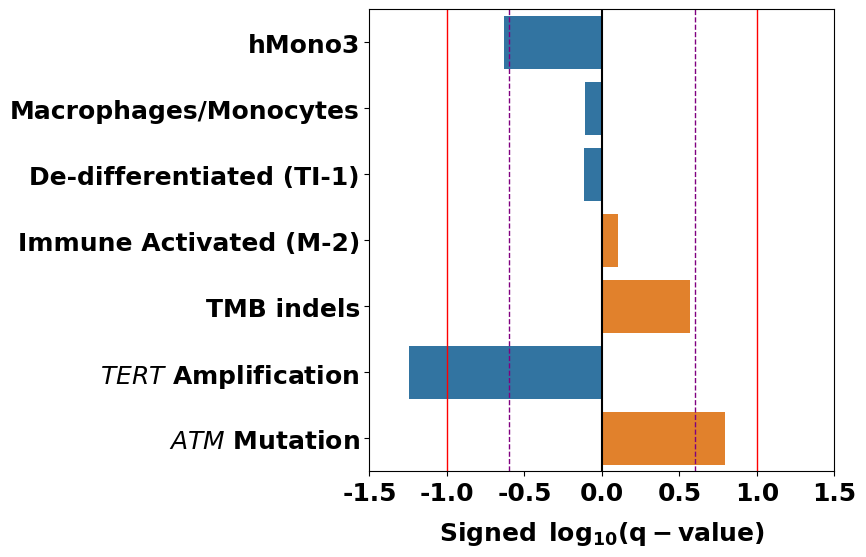

In [148]:
df_plot=df_subset[df_subset['subset']=='High TMB'].sort_values(by='cluster')
plt.figure(figsize=(6,6))
ylabels = ['hMono3','Macrophages/Monocytes','De-differentiated (TI-1)',
           'Immune Activated (M-2)','TMB indels',
           '$\it{TERT}$ Amplification','$\it{ATM}$ Mutation']
h = sns.barplot(y=df_plot['feature'],x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['favorable'],dodge=False)
ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]
plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')
plt.ylabel(None)
plt.setp(ax.get_yticklabels(),font = 'Arial',fontsize=18,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=18)
plt.xlim(-1.5,1.5)
plt.ylim(6.5,-0.5)
h.set_yticklabels(ylabels)
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=18,labelpad=10)
ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=18)
h.legend_.remove()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

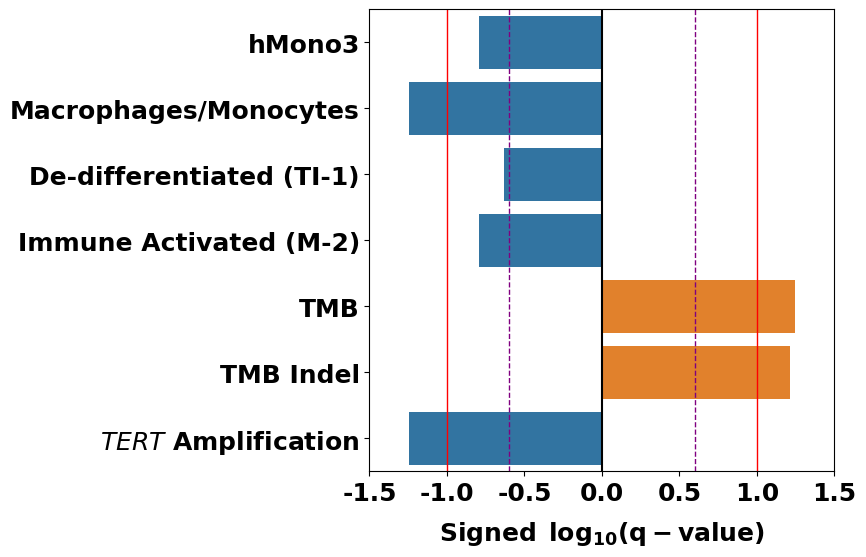

In [149]:
df_plot=df_subset[df_subset['subset']=='High PDL1'].sort_values(by='cluster')
plt.figure(figsize=(6,6))
ylabels = ['hMono3','Macrophages/Monocytes','De-differentiated (TI-1)','Immune Activated (M-2)','TMB','TMB Indel','$\it{TERT}$ Amplification','$\it{ATM}$ Mutation']
h = sns.barplot(y=df_plot['feature'],x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['favorable'],dodge=False)
ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]
plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')
plt.ylabel(None)
plt.setp(ax.get_yticklabels(),font = 'Arial',fontsize=18,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.xlim(-1.5,1.5)
plt.ylim(6.5,-0.5)
h.set_yticklabels(ylabels)    
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=18,labelpad=10)
ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=18)
h.legend_.remove()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

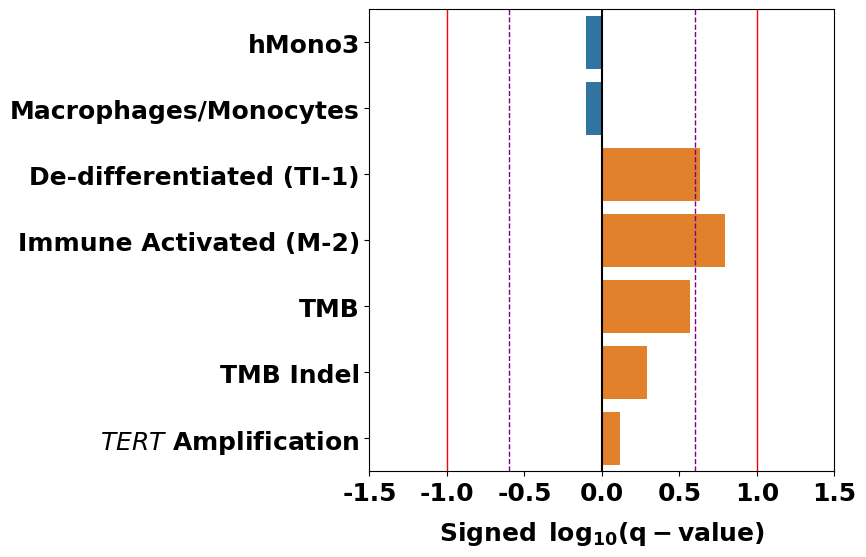

In [150]:
df_plot=df_subset[df_subset['subset']=='Low PDL1'].sort_values(by='cluster')
plt.figure(figsize=(6,6))
ylabels = ['hMono3','Macrophages/Monocytes','De-differentiated (TI-1)','Immune Activated (M-2)','TMB','TMB Indel','$\it{TERT}$ Amplification','$\it{ATM}$ Mutation']
h = sns.barplot(y=df_plot['feature'],x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['favorable'],dodge=False)
ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]
plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')
plt.ylabel(None)
plt.setp(ax.get_yticklabels(),font = 'Arial',fontsize=18,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.xlim(-1.5,1.5)
plt.ylim(6.5,-0.5)
h.set_yticklabels(ylabels)    
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=18,labelpad=10)
ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=18)
h.legend_.remove()

## Biomarker PFS Plots

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

<Figure size 800x400 with 0 Axes>

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

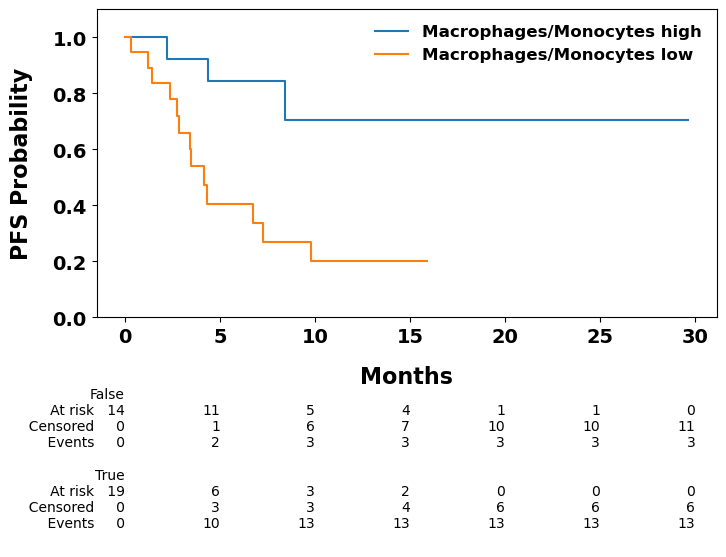

In [151]:
plt.figure(figsize=(8,4))

feature_col = 'Macrophages/Monocytes_SF'
duration_col = 'Harmonized_PFS_Months'
event_col = 'Harmonized_PFS_Event'

df = su2c_merge_master[su2c_merge_master['PDL1_TPS']>=.5]
df_filt = df[[feature_col,duration_col,event_col]].dropna()
df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>0)

medpfs, ax = survival_curve_pair(df_filt,feature_col,duration_col,event_col)

plt.ylim(0,1.1)
ax.set_ylabel("PFS Probability",font='Arial',weight='bold',fontsize=16,labelpad = 14)
ax.set_xlabel("Months",font='Arial',weight='bold',fontsize=16,labelpad=14)
ax.set_xticklabels(np.round(ax.get_xticks()),font='Arial',weight='bold',fontsize=14)
ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)
L = ax.legend(frameon=False,prop={'size':12,'weight':'bold'})
L.get_texts()[0].set_text("Macrophages/Monocytes high")
L.get_texts()[1].set_text("Macrophages/Monocytes low")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
fig = plt.gcf()
fig.set_size_inches(8, 4)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

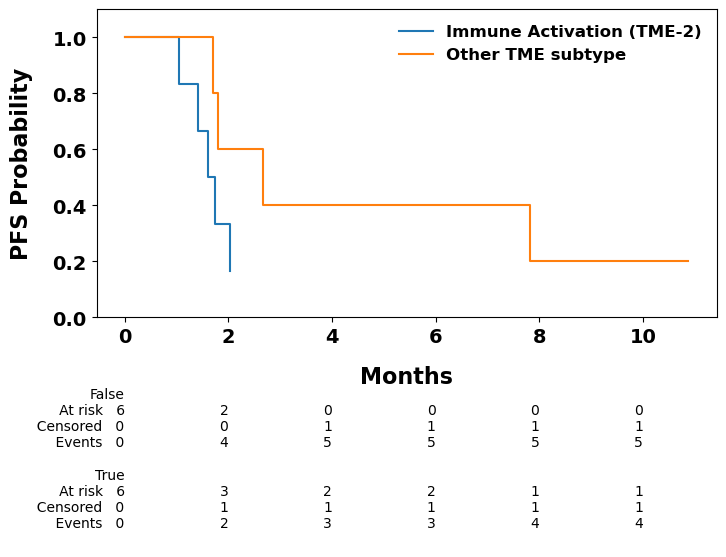

In [152]:
feature_col = 'I2_norm'
duration_col = 'Harmonized_PFS_Months'
event_col = 'Harmonized_PFS_Event'

df = su2c_merge_master[su2c_merge_master['PDL1_TPS']<0.01]
df_filt = df[[feature_col,duration_col,event_col]].dropna()
med = su2c_merge_master[feature_col].median()

df_filt[feature_col] = (df_filt[feature_col]>med)

medpfs, ax = survival_curve_pair(df_filt,feature_col,duration_col,event_col)
plt.ylim(0,1.1)
ax.set_ylabel("PFS Probability",font='Arial',weight='bold',fontsize=16,labelpad = 14)
ax.set_xlabel("Months",font='Arial',weight='bold',fontsize=16,labelpad=14)
ax.set_xticklabels(np.round(ax.get_xticks()),font='Arial',weight='bold',fontsize=14)
ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)
L = ax.legend(frameon=False,prop={'size':12,'weight':'bold'})
L.get_texts()[0].set_text("Immune Activation (TME-2)")
L.get_texts()[1].set_text("Other TME subtype")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
fig = plt.gcf()
fig.set_size_inches(8, 4)